**Import the useful packages** 

In [1]:
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import os,sys
import pandas as pd

# To avoid problems with tensorflow, add the following lines before importing it
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow import keras

# To avoid problems with nn_functions, add the following lines before importing it 
import sys
sys.path.insert(1, '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt')

#from nn_functions.constants import *
#import nn_functions.diagnostic_functions as diag
#import nn_functions.data_formatting as dfmt
import nn_functions.postprocessing_functions as pp
#from nn_functions.constants import *

import define_params 

# For plotting things on the polar stereographic grid with lat and lon coordinates 
import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

**Set the filepaths to the input and output data** 

In [2]:
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'

models = glob.glob(path_model + '*.keras')
histories = glob.glob(path_model + 'history*.csv')

#fp_all_data = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv'


In [3]:
#mod_size = 'small'
#TS_opt = 'extrap'
#norm_method = 'std'
#exp_name = 'slope_front'
#annual_f = ''
#seed_nb = 1
#this_collection = 'no_middle_5'
#np.random.seed(seed_nb)
#tf.random.set_seed(seed_nb)

In [4]:
models_unique = []
for i in range(len(models)):
    models_unique.append(models[i].split(os.path.sep)[7].split('_extrap_std.keras')[0][:-3])
print(np.unique(models_unique))

['model_nn_small_slope_front_OPM026_to1988'
 'model_nn_small_slope_front_OPM026_to1998'
 'model_nn_small_slope_front_OPM026_to2008'
 'model_nn_small_slope_front_OPM026_to2018'
 'model_nn_small_slope_front_OPM026_to2028'
 'model_nn_small_slope_front_OPM026_to2038'
 'model_nn_small_slope_front_OPM026_to2048'
 'model_nn_small_slope_front_OPM026_to2058'
 'model_nn_small_slope_front_OPM026_whole_dataset'
 'model_nn_small_slope_front_after_1984'
 'model_nn_small_slope_front_no_jun_dec'
 'model_nn_small_slope_front_no_mar_oct'
 'model_nn_small_slope_front_no_middle_5'
 'model_nn_small_slope_front_up_to_2018'
 'model_nn_small_slope_front_whole_dataset'
 'model_nn_small_slope_lat_lon_no_middle_5'
 'model_nn_small_slope_lat_lon_whole_dataset']


### **Apply a trained nn to the test data set**

Create functions to:
- Load in the test data
- Load in the neural network model
- Load in the normalisation metrics for the training/validation dataset used to train the model
- Apply the neural network model to the normalised test data

In [48]:
OMP026 = load_test_data_whole_sim('OPM026_whole_dataset', keep_pandas = False)

You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM026_whole_dataset_not_yet_normalised.csv
You have kept the whole dataset


In [49]:
OMP0263 = load_test_data_whole_sim('OPM0263_whole_dataset', keep_pandas = False)

You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM0263_whole_dataset_not_yet_normalised.csv
You have kept the whole dataset


In [5]:
# Load in all the data
def load_test_data_whole_sim(this_collection, verbose = 0, keep_pandas = False):
    fp_apply = path_norm_metrics + this_collection + '_not_yet_normalised.csv'
    df_sel = pd.read_csv(fp_apply)
    print('\033[1m' + 'You have loaded data to apply the nn to:' + '\033[0m')
    print(fp_apply)
    print('You have kept the whole dataset')
    # Convert imported data to xarray
    if keep_pandas == False:
        clean_df = df_sel.to_xarray()
        return clean_df
    else:
        return df_sel

In [6]:
# Set the model filepath and load the normalisation metrics 
def load_model_nn(exp_name, this_collection, seed_nb, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, 
                 annual_f = ''):
    fp_model = path_model + 'model_nn_'+ mod_size + '_' +exp_name + '_' + this_collection + '_' + annual_f + \
                                    str(seed_nb).zfill(2) + '_' + TS_opt + '_' + norm_method + '.keras'
    model = keras.models.load_model(fp_model)
    if verbose == 1:
        print('\033[1m' + 'You have loaded a trained neural network:' + '\033[0m')
        print(fp_model)
    return model
    
def load_normalisation_metrics(this_collection, norm_method = 'std', verbose = 0):
    fp_norm_metrics = path_norm_metrics + this_collection + '_metrics_norm.nc'
    norm_metrics_file = xr.open_dataset(fp_norm_metrics)
    if verbose > 0:
        print('\033[1m' + 'You have loaded normalisation metrics:' + '\033[0m')
        print(fp_norm_metrics)
    norm_metrics = norm_metrics_file.sel(norm_method=norm_method).drop('norm_method').to_dataframe()
    return norm_metrics

In [7]:
this_collection_NN = 'OPM026_whole_dataset'
this_collection_apply = 'OPM0263_whole_dataset'
exp_name = 'slope_front'

model = load_model_nn(exp_name, this_collection_NN, seed_nb = 1)

In [8]:
clean_df = load_test_data_whole_sim(this_collection_apply, keep_pandas = True)

You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM0263_whole_dataset_not_yet_normalised.csv
You have kept the whole dataset


In [9]:
clean_df

,lat,lon,distances_GL,distances_OO,distances_OC,temperature_prop,salinity_prop,melt_m_ice_per_y,corrected_isdraft,bathymetry,...,slope_ba_across_front,slope_ba_towards_front,mean_T,mean_S,std_T,std_S,year,month,basins_NEMO,area
0,-85.368385,-154.12903,3824.406974,737830.168777,143376.499204,-2.067472,34.902687,-0.000062,965.817993,1012.748047,...,-0.006261,-0.005423,-2.081409,34.894125,0.034217,0.020703,1979,1,59.0,17020146.0
1,-85.365005,-153.69621,4287.263604,738553.726966,146370.510902,-2.067472,34.902687,-0.000070,965.817993,1064.429688,...,0.006605,0.005721,-2.081409,34.894125,0.034217,0.020703,1979,1,59.0,17000464.0
2,-85.361430,-153.26420,4284.087686,739302.729521,149404.836207,-2.067472,34.902687,-0.000085,1012.748047,1064.429688,...,-0.000000,-0.000000,-2.081409,34.894125,0.034217,0.020703,1979,1,59.0,16980548.0
3,-85.357635,-152.83304,4281.868166,740075.392643,152476.030358,-2.067472,34.902687,-0.000060,1012.748047,1064.429688,...,-0.000000,-0.000000,-2.081409,34.894125,0.034217,0.020703,1979,1,59.0,16960430.0
4,-85.353645,-152.40274,3814.478693,740873.095699,155582.530413,-2.067472,34.902687,-0.000025,943.754639,988.770020,...,-0.012261,-0.010620,-2.081409,34.894125,0.034217,0.020703,1979,1,59.0,16940084.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7841275,-65.183850,96.75000,35559.457984,23889.900394,11944.978624,-1.917147,34.445835,-0.000009,209.438217,350.019897,...,0.001874,0.000364,-1.875911,34.495452,0.025847,0.037968,2018,12,26.0,136136800.0
7841276,-65.183850,97.00000,37487.387426,11944.978624,11944.978624,-1.871105,34.476154,-0.000011,153.289978,366.233521,...,0.001898,0.000369,-1.875911,34.495452,0.025847,0.037968,2018,12,26.0,136136800.0
7841277,-65.078710,97.00000,48982.662530,11997.152819,11997.152819,-1.864803,34.474754,-0.000013,127.891647,366.233521,...,-0.000000,-0.000000,-1.875911,34.495452,0.025847,0.037968,2018,12,26.0,137218940.0
7841278,-65.078710,-60.75000,26878.520294,11957.454165,11957.454165,-1.849592,34.686836,-0.000016,140.326645,317.824951,...,0.007787,-0.007787,-1.637966,34.664328,0.211625,0.022509,2018,12,113.0,137218940.0


In [42]:
clean_df2 = clean_df[::1000].to_xarray()

In [43]:
clean_df2

<xarray.Dataset>
Dimensions:                 (index: 7842)
Coordinates:
  * index                   (index) int64 0 1000 2000 ... 7840000 7841000
Data variables: (12/25)
    lat                     (index) float64 -85.37 -83.07 ... -70.25 -66.61
    lon                     (index) float64 -154.1 -75.43 -66.69 ... 7.253 108.0
    distances_GL            (index) float64 3.824e+03 4.531e+03 ... 1.12e+04
    distances_OO            (index) float64 7.378e+05 7.451e+05 ... 1.124e+04
    distances_OC            (index) float64 1.434e+05 1.804e+05 ... 1.124e+04
    temperature_prop        (index) float64 -2.067 -1.945 ... -1.816 -1.774
    ...                      ...
    mean_S                  (index) float64 34.89 34.86 34.86 ... 34.49 34.58
    std_T                   (index) float64 0.03422 0.05125 ... 0.05286 0.03833
    std_S                   (index) float64 0.0207 0.0569 ... 0.02808 0.01367
    year                    (index) int64 1979 1979 1979 1979 ... 2018 2018 2018
    month                   (index) int64 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12
    basins_NEMO             (index) float64 59.0 98.0 98.0 99.0 ... 8.0 9.0 29.0

In [12]:
norm_metrics = load_normalisation_metrics(this_collection_NN)

In [44]:
val_norm = pp.normalise_vars(clean_df2,
                        norm_metrics.loc['mean_vars'],
                        norm_metrics.loc['range_vars'])
# Import the desired variables, and create a list 
var_list = define_params.var_list_by_exp_name(exp_name)
input_vars = list(np.array(var_list)[~(np.array(var_list) == 'melt_m_ice_per_y')])
# Split into input and reference datasets
x_val_norm = val_norm[input_vars]
y_val_norm = val_norm['melt_m_ice_per_y']
# Apply the model 
#shape = x_val_norm.to_array().values.shape[1], x_val_norm.to_array().values.shape[0]
#y_out_norm = model.predict(x_val_norm.to_array().values.reshape(shape),verbose = 0)
y_out_norm = model.predict(x_val_norm.to_array().values.T,verbose = 0)
y_out_norm_xr = xr.DataArray(data=y_out_norm.squeeze()).rename({'dim_0': 'index'})
y_out_norm_xr = y_out_norm_xr.assign_coords({'index': x_val_norm.index})    
# denormalise the output
y_out = pp.denormalise_vars(y_out_norm_xr, 
                         norm_metrics['melt_m_ice_per_y'].loc['mean_vars'],
                         norm_metrics['melt_m_ice_per_y'].loc['range_vars'])

In [45]:
melt_pred = clean_df2.melt_m_ice_per_y.data

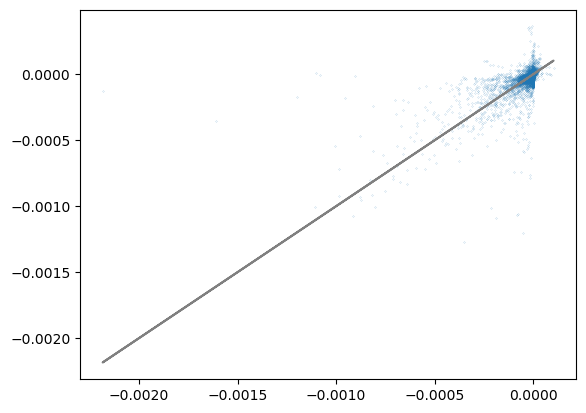

In [48]:
plt.scatter(melt_pred, y_out, s = 0.01)
plt.plot(melt_pred, melt_pred, color = 'grey')

In [24]:
x_val_norm[:,50]#, y_val_norm

KeyError: (slice(None, None, None), 50)

In [7]:
def apply_model(model, norm_metrics, clean_df, exp_name, verbose = 0):
    # First normalise input data 
    val_norm = pp.normalise_vars(clean_df,
                            norm_metrics.loc['mean_vars'],
                            norm_metrics.loc['range_vars'])
    # Import the desired variables, and create a list 
    var_list = define_params.var_list_by_exp_name(exp_name)
    input_vars = list(np.array(var_list)[~(np.array(var_list) == 'melt_m_ice_per_y')])
    # Split into input and reference datasets
    x_val_norm = val_norm[input_vars]
    y_val_norm = val_norm['melt_m_ice_per_y']
    # Apply the model 
    #shape = x_val_norm.to_array().values.shape[1], x_val_norm.to_array().values.shape[0]
    #y_out_norm = model.predict(x_val_norm.to_array().values.reshape(shape),verbose = 0)
    y_out_norm = model.predict(x_val_norm.to_array().values.T,verbose = 0)
    y_out_norm_xr = xr.DataArray(data=y_out_norm.squeeze()).rename({'dim_0': 'index'})
    y_out_norm_xr = y_out_norm_xr.assign_coords({'index': x_val_norm.index})    
    # denormalise the output
    y_out = pp.denormalise_vars(y_out_norm_xr, 
                             norm_metrics['melt_m_ice_per_y'].loc['mean_vars'],
                             norm_metrics['melt_m_ice_per_y'].loc['range_vars'])
    if verbose > 0:
        print('\033[1m' + 'You have applied the neural network to the chosen data:' + '\033[0m')
    return y_out

In [8]:
def apply_nn_save_results(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, annual_only = False, 
                         apply_collection = None, annual_f = ''):
    if apply_collection == None:
        load_collection = this_collection
    else:
        load_collection = apply_collection
    norm_metrics = load_normalisation_metrics(this_collection, verbose = verbose)
    clean_df = load_test_data_whole_sim(load_collection, verbose = verbose)
    if annual_only == True:
        # Get just the annual data 
        clean_pdf = clean_df.to_dataframe()
        df_annual = clean_pdf.groupby(['lat','lon','year'], as_index = False).mean()
        clean_df = df_annual.to_xarray()
    seed_nb_array = np.arange(1,11,1)
    list_melt_seeds = []
    df_ref_pred = pd.DataFrame({'lat': clean_df.lat, 
                                'lon': clean_df.lon,
                                'basin': clean_df.basins_NEMO,
                                'area': clean_df.area, #clean_df.approx_area for OPM026?
                                'year': clean_df.year, 
                                'month': clean_df.month, 
                                'melt_m_ice_per_y': clean_df.melt_m_ice_per_y})
    for i in range(len(seed_nb_array)):
        list_melt_seeds.append('melt_' + str(i+1).zfill(2))
        if verbose == 2:
            model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 1, annual_f = annual_f) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 1)
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed', end = '\r')
        else:
            model = load_model_nn(exp_name, this_collection, seed_nb_array[i], \
                              mod_size = mod_size, TS_opt = TS_opt, norm_method = norm_method, \
                              verbose = 0) 
            df_ref_pred['melt_' + str(i+1).zfill(2)] = apply_model(model, norm_metrics, clean_df, exp_name, verbose = 0)
            print(seed_nb_array[i], 'out of', len(seed_nb_array), 'processed', end = '\r')
    # Calculate the ensemble mean 
    df_ref_pred['melt_pred_mean'] = np.mean(df_ref_pred[list_melt_seeds], axis = 1).values
    
    # If you want to make the files smaller, you can save the results with just the ensemble mean
    # by setting keep_all_runs to False 
    if keep_all_runs == False:
        df_ref_pred_save = df_ref_pred[list(df_ref_pred.columns.values[~np.isin(list(df_ref_pred.columns.values), list_melt_seeds)])]
        print('Warning, you have not saved the results of each nn, just the ensemble mean')
        sims = 'just_mean'
    else:
        df_ref_pred_save = df_ref_pred
        print('You have saved the results of each nn, and the ensemble mean')
        sims = 'all_sims'
    # Set the filepath and save the output
    if annual_only == False:
        ano = ''
    else:
        ano = '_annual'
    if load_collection == True:
        lc = ''
    else:
        ano = ano + '_special_lc_' + load_collection
    fp_ref_pred = path_model + 'applied_nn' + '_' + mod_size + '_' +exp_name + '_' + this_collection + '_' + annual_f + \
                                        sims + '_' + TS_opt + '_' + norm_method + ano + '.csv'
    df_ref_pred.to_csv(fp_ref_pred, index = False)
    if verbose > 0:
        print('\033[1m' + 'You have saved the results of applying the neural network to the test dataset:' + '\033[0m')
        print(fp_ref_pred)

**Apply the neural network to the test data (aka data not used for training)**

In [9]:
np.unique(models_unique)

array(['model_nn_small_slope_front_OPM026_to1988',
       'model_nn_small_slope_front_OPM026_to1998',
       'model_nn_small_slope_front_OPM026_to2008',
       'model_nn_small_slope_front_OPM026_to2018',
       'model_nn_small_slope_front_OPM026_to2028',
       'model_nn_small_slope_front_OPM026_to2038',
       'model_nn_small_slope_front_OPM026_to2048',
       'model_nn_small_slope_front_OPM026_to2058',
       'model_nn_small_slope_front_OPM026_whole_dataset',
       'model_nn_small_slope_front_after_1984',
       'model_nn_small_slope_front_no_jun_dec',
       'model_nn_small_slope_front_no_mar_oct',
       'model_nn_small_slope_front_no_middle_5',
       'model_nn_small_slope_front_up_to_2018',
       'model_nn_small_slope_front_whole_dataset',
       'model_nn_small_slope_lat_lon_no_middle_5',
       'model_nn_small_slope_lat_lon_whole_dataset'], dtype='<U47')

In [12]:
%%time
this_collection_NN = 'OPM026_to2018'
this_collection_apply = 'OPM0263_whole_dataset'
exp_name = 'slope_front'

apply_nn = True
if apply_nn == True:
    apply_nn_save_results(this_collection_NN, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 2, annual_only = False, 
                         apply_collection = this_collection_apply, annual_f = '')
else:
    print('No neural network applied, change apply_nn to True if desired')

You have loaded normalisation metrics:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM026_to2018_metrics_norm.nc
You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/OPM0263_whole_dataset_not_yet_normalised.csv
You have kept the whole dataset
You have loaded a trained neural network:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/model_nn_small_slope_front_OPM026_to2018_01_extrap_std.keras
You have applied the neural network to the chosen data:
You have loaded a trained neural network:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/model_nn_small_slope_front_OPM026_to2018_02_extrap_std.keras
You have applied the neural network to the chosen data:
You have loaded a trained neural network:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/model_nn_small_slope_front_OPM026_to2018_03_extrap_std.keras
You have applied the neural network to the chosen data:
You

### **Start here if you want to look at results which have already been processed**

In [5]:
def load_results_nn(this_collection, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, annual_only = False,
                   apply_collection = None, annual_f = ''):
    if apply_collection == None:
        load_collection = this_collection
    else:
        load_collection = apply_collection
    if keep_all_runs == False:
        sims = 'just_mean'
    else:
        sims = 'all_sims'
    if annual_only == False:
        ano = ''
    else:
        ano = '_annual'
    if load_collection == True:
        lc = ''
    else:
        ano = ano + '_special_lc_' + load_collection
    fp_ref_pred = path_model + 'applied_nn' + '_' + mod_size + '_' + exp_name + '_' + this_collection + '_' + annual_f + \
                                        sims + '_' + TS_opt + '_' + norm_method + ano + '.csv'
    df_ref_pred = pd.read_csv(fp_ref_pred)
    if verbose == 1:
        print('\033[1m' + 'You have loaded the results of applying the neural network to the test dataset:' + '\033[0m')
        print(fp_ref_pred)
    df_ref_pred.loc[:,'melt_Gt_per_y'] = ((df_ref_pred.loc[:,'melt_m_ice_per_y'] * df_ref_pred.loc[:,'area']* 31536000) * 1/1e12)
    df_ref_pred.loc[:,'melt_pred_Gt'] = ((df_ref_pred.loc[:,'melt_pred_mean'] * df_ref_pred.loc[:,'area'] * 31536000) * 1/1e12)
    #if verbose == 1:
    #    print('You have converted the melt to Gt per yr')
    return df_ref_pred

from sklearn.linear_model import LinearRegression as regres
# Linear regression model creation and fitting
def regression_analysis(ref_melt, pred_melt):
    ref_melt = ref_melt.values.reshape(-1,1)
    pred_melt = pred_melt.values.reshape(-1,1)
    model = regres()
    reg = model.fit(ref_melt, pred_melt)
    slope = reg.coef_[0][0] 
    intercept = reg.intercept_[0]
    rsq = reg.score(ref_melt, pred_melt)
    return slope, intercept, rsq

In [6]:
df_ref_pred = load_results_nn(this_collection_NN, exp_name, keep_all_runs = True, \
                         mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, annual_only = False,
                   apply_collection = this_collection_apply, annual_f = '')
df_ref_pred = df_ref_pred[df_ref_pred.year > 1983]

In [7]:
regression_analysis(df_ref_pred.melt_Gt_per_y, df_ref_pred.melt_pred_Gt)

(0.8052638465573347, -0.009041996296508988, 0.7224677380588753)

In [8]:
basin_nos = np.unique(df_ref_pred.basin)

In [9]:
df_ymb = df_ref_pred.groupby(['year','month', 'basin'], as_index = False).sum()
df_yb = df_ref_pred.groupby(['year', 'basin'], as_index = False).sum()

In [10]:
df_ym = df_ref_pred.groupby(['year','month'], as_index = False).sum()

In [11]:
df_y = df_ym.groupby('year', as_index = False).mean()

In [12]:
df_m = df_ym.groupby('month', as_index = False).mean()

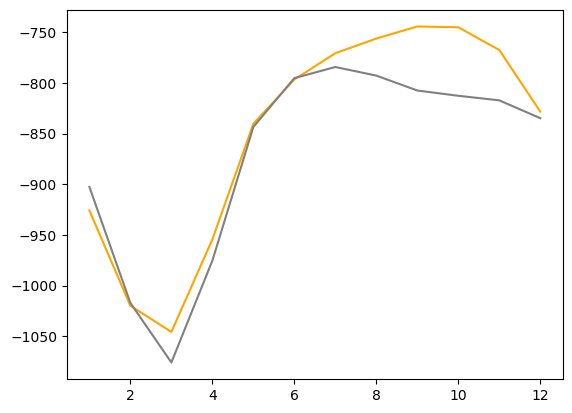

In [13]:
plt.plot(df_m.month, df_m.melt_pred_Gt, color = 'orange')
plt.plot(df_m.month, df_m.melt_Gt_per_y, color = 'grey')

In [14]:
#import matplotlib
#matplotlib.rc('axes',edgecolor='black', facecolor = 'white')

In [15]:
plt.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

In [16]:
np.arange(1984, 2019,2)

array([1984, 1986, 1988, 1990, 1992, 1994, 1996, 1998, 2000, 2002, 2004,
       2006, 2008, 2010, 2012, 2014, 2016, 2018])

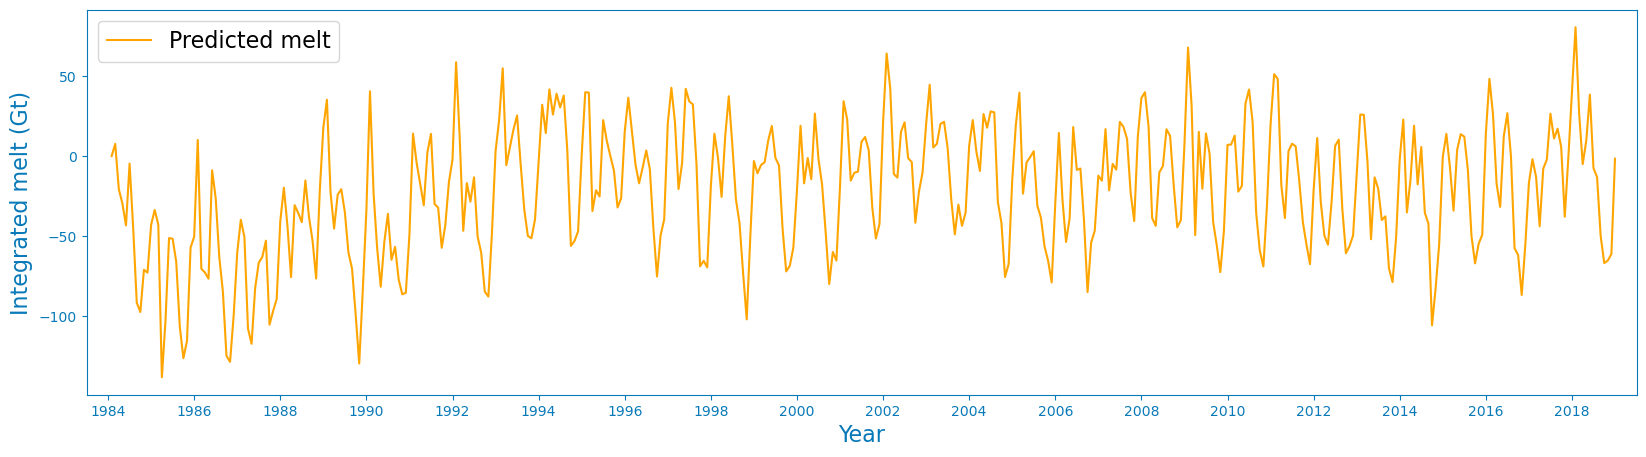

In [17]:

with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
                    'axes.labelcolor':'#0879B8'}):
    fig, ax = plt.subplots(1,1, figsize = (20,5))   
    ax.plot(df_ym.year+df_ym.month/12, df_ym.melt_Gt_per_y-df_ym.melt_pred_Gt, color = 'orange', label = 'Predicted melt')
    ax.set_xlim(1983.5,2019.5)
    ax.set_xlabel('Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt)', fontsize = 16)
    ax.set_xticks(np.arange(1984, 2019,2))
    ax.legend(fontsize = 16)
    fig.savefig('FIGURES/Integrated_melt.pdf')
#0879B8

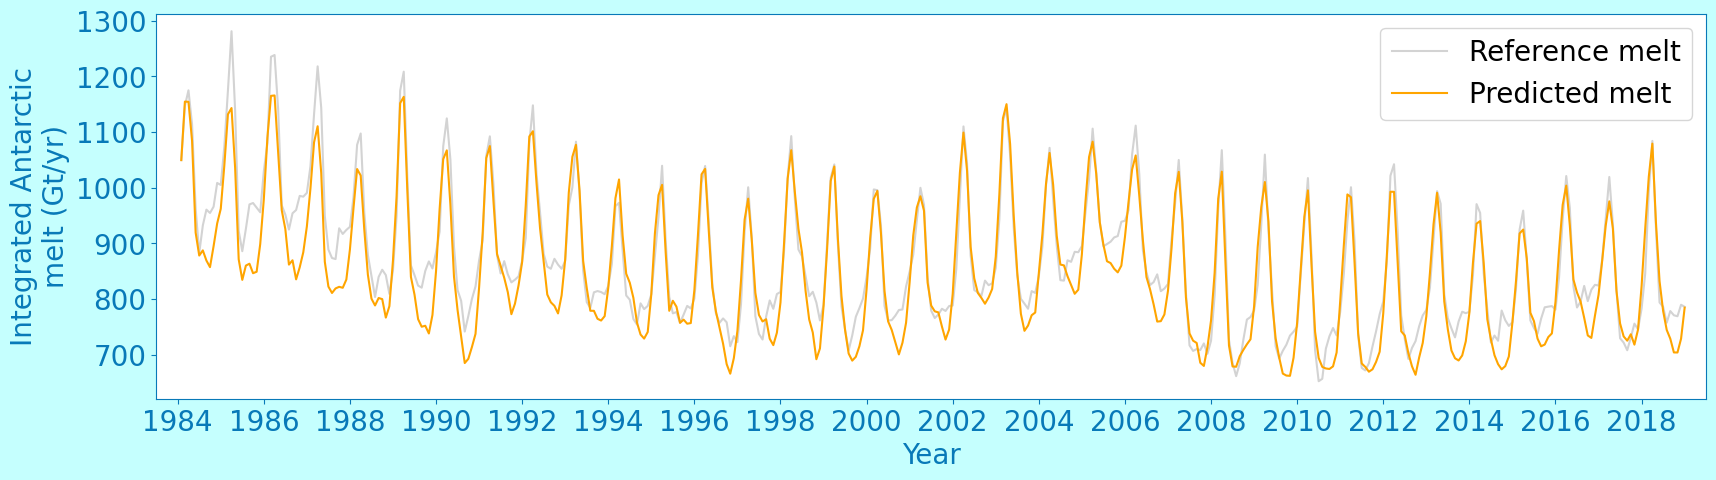

In [47]:

with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5fffe', 'axes.facecolor': 'white', 'font.size': 20}):
    fig, ax = plt.subplots(1,1, figsize = (20,5))   
    ax.plot(df_ym.year+df_ym.month/12, -df_ym.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt')
    ax.plot(df_ym.year+df_ym.month/12, -df_ym.melt_pred_Gt, color = 'orange', label = 'Predicted melt')
    ax.set_xlim(1983.5,2019.5)
    ax.set_xlabel('Year')
    ax.set_ylabel('Integrated Antarctic\nmelt (Gt/yr)')
    ax.set_xticks(np.arange(1984, 2019,2))
    ax.legend()
    fig.savefig('FIGURES/Integrated_melt.png', dpi = 200, bbox_inches = 'tight')
#0879B8

In [19]:
np.sum(df_ymb[df_ymb.melt_Gt_per_y < -100].basin == 143)

0

In [20]:
big_basins = np.unique(df_ymb[df_ymb.melt_Gt_per_y < -100].basin)
for i in range(len(big_basins)):
    print(big_basins[i], np.sum(df_ymb[df_ymb.melt_Gt_per_y < -100].basin == big_basins[i]))

108.0 49
125.0 420


In [21]:
reg_ymb = regression_analysis(df_ymb.melt_Gt_per_y, df_ymb.melt_pred_Gt)

In [22]:
regression_analysis(df_yb.melt_Gt_per_y, df_yb.melt_pred_Gt)

(0.9786910204614437, 0.29056300481315134, 0.9704544657352452)

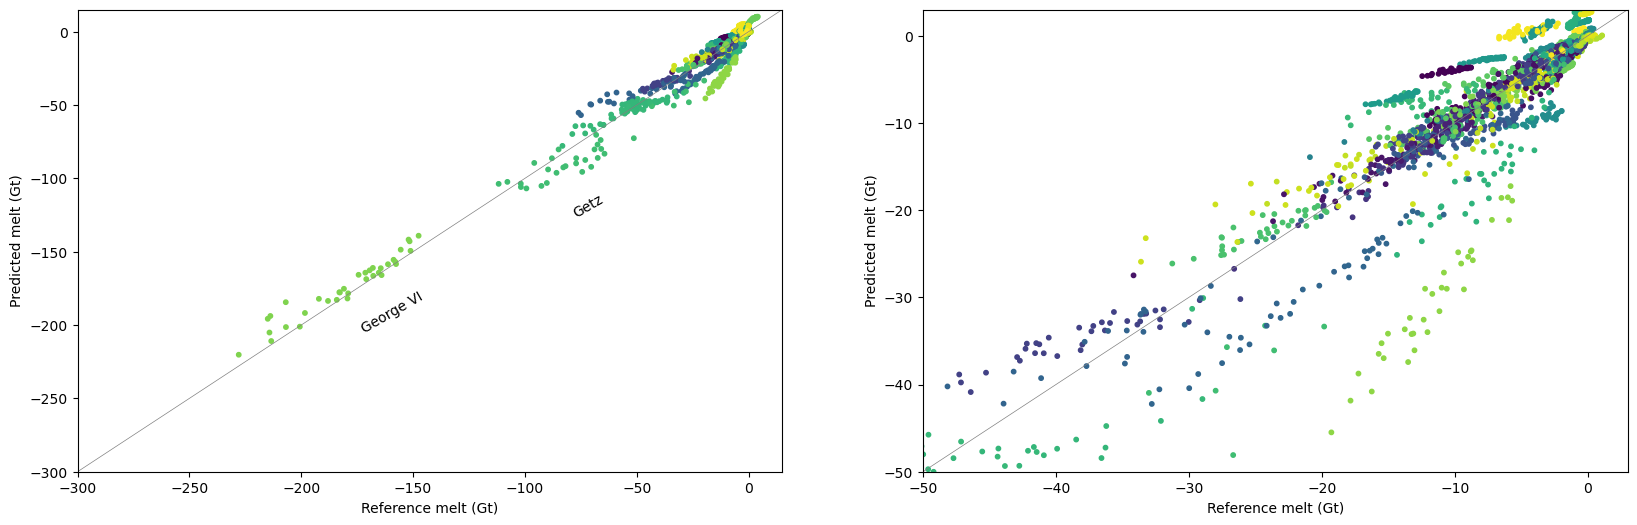

In [23]:
fig, ax = plt.subplots(1,2, figsize = (20,6))
ax[0].scatter(df_yb.melt_Gt_per_y/12, df_yb.melt_pred_Gt/12, s = 10, alpha = 1, c = df_yb.basin)
ax[1].scatter(df_yb.melt_Gt_per_y/12, df_yb.melt_pred_Gt/12, s = 10, alpha = 1, c = df_yb.basin)
lims = [(-2600/12,100/12), (-500/12,100/12)]
lims = [(-300,15),(-50,3)]
for i in range(2):
    ax[i].set_xlabel('Reference melt (Gt)')
    ax[i].set_ylabel('Predicted melt (Gt)')
    ax[i].set_xlim(lims[i])
    ax[i].set_ylim(lims[i])
#plt.xlim(-250,20)
#plt.ylim(-250,20)
#plt.xticks((-0.002,-0.001,0))
#plt.yticks((-0.002,-0.001,0))
    ax[i].plot((-2500,20),(-2500,20), color = 'grey', zorder  = 1, linewidth = 0.5)
ax[0].annotate('George VI', xy = (0,0), xytext = (0.4,0.3), xycoords = 'axes fraction', rotation = 30);
ax[0].annotate('Getz', xy = (0,0), xytext = (0.7,0.55), xycoords = 'axes fraction', rotation = 30);

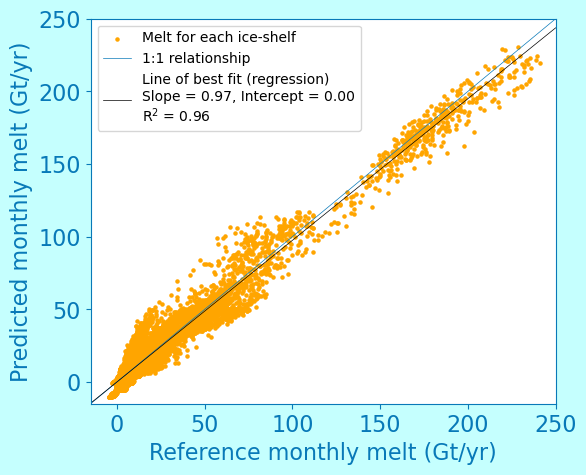

In [44]:
with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5fffe', 'axes.facecolor': 'white', 'font.size': 16}):
    fig, ax = plt.subplots(1,1, figsize = (6,5))
    ax.scatter(-df_ymb.melt_Gt_per_y, -df_ymb.melt_pred_Gt, s = 5, alpha = 1, c = 'orange', label = 'Melt for each ice-shelf')
    lims = [(-15,250),(-15,250)]

    
    
    ax.set_xlabel('Reference monthly melt (Gt/yr)')
    ax.set_ylabel('Predicted monthly melt (Gt/yr)')
    ax.set_xlim(lims[0])
    ax.set_ylim(lims[0])
    ax.plot((-20,250),(-20,250), color = '#0879B8', zorder  = 1, linewidth = 0.5, label = '1:1 relationship', linestyle = '-')
    ax.plot((-20,250),(-20*reg_ymb[0]+reg_ymb[1],250*reg_ymb[0]+reg_ymb[1]), color = 'k', \
            zorder  = 1, linewidth = 0.5, \
            label = 'Line of best fit (regression)\nSlope = {:.2f}, \
Intercept = {:.2f}\nR$^2$ = {:.2f}'.format(reg_ymb[0], reg_ymb[1], reg_ymb[2]))
    ax.legend(fontsize = 10)
fig.savefig('FIGURES/Melt_ymb.png', dpi = 200, bbox_inches = 'tight')

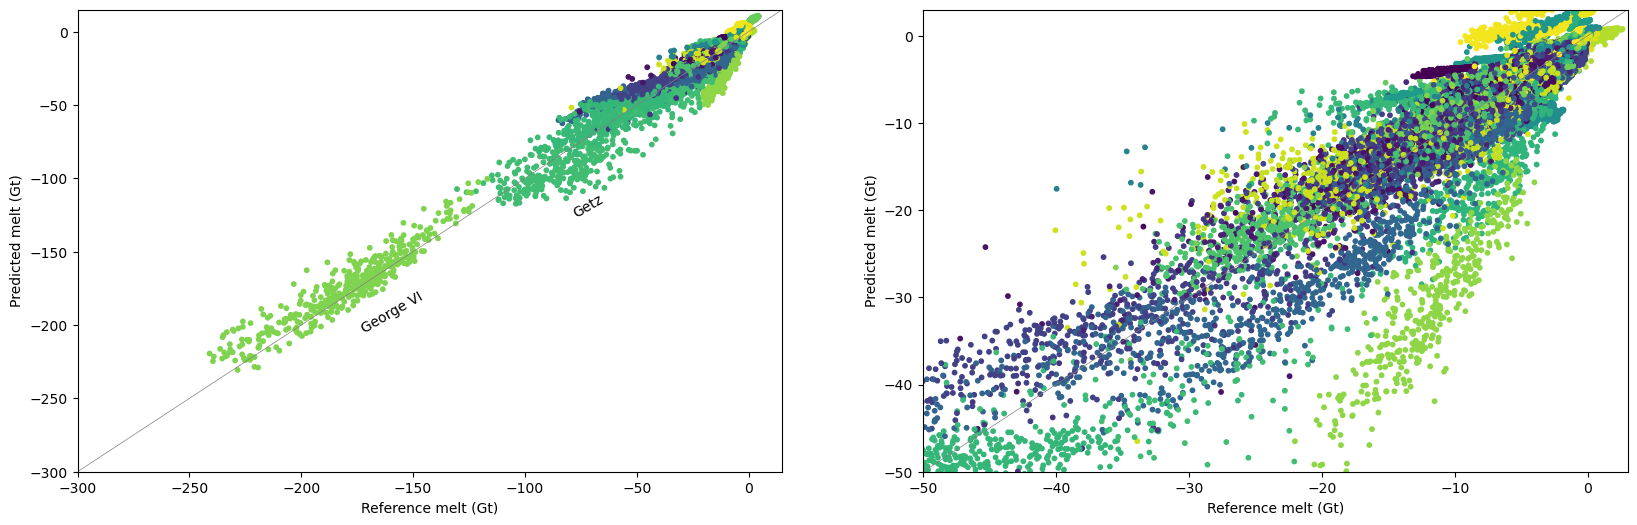

In [25]:
fig, ax = plt.subplots(1,2, figsize = (20,6))
ax[0].scatter(df_ymb.melt_Gt_per_y, df_ymb.melt_pred_Gt, s = 10, alpha = 1, c = df_ymb.basin)
ax[1].scatter(df_ymb.melt_Gt_per_y, df_ymb.melt_pred_Gt, s = 10, alpha = 1, c = df_ymb.basin)
lims = [(-2600,100), (-500,10)]
lims = [(-300,15),(-50,3)]
for i in range(2):
    ax[i].set_xlabel('Reference melt (Gt)')
    ax[i].set_ylabel('Predicted melt (Gt)')
    ax[i].set_xlim(lims[i])
    ax[i].set_ylim(lims[i])
#plt.xlim(-250,20)
#plt.ylim(-250,20)
#plt.xticks((-0.002,-0.001,0))
#plt.yticks((-0.002,-0.001,0))
    ax[i].plot((-2500,20),(-2500,20), color = 'grey', zorder  = 1, linewidth = 0.5)
ax[0].annotate('George VI', xy = (0,0), xytext = (0.4,0.3), xycoords = 'axes fraction', rotation = 30);
ax[0].annotate('Getz', xy = (0,0), xytext = (0.7,0.55), xycoords = 'axes fraction', rotation = 30);

In [26]:
i = 143

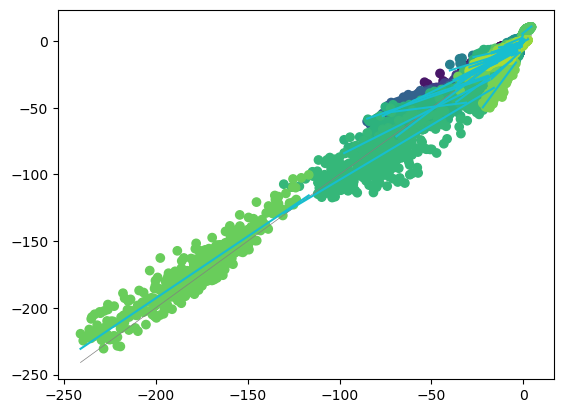

In [27]:
slopes = np.ones(len(basin_nos))
intercepts = np.ones(len(basin_nos))
rsqs = np.ones(len(basin_nos))
for i in range(len(basin_nos)):
    #print(i)
    just_basin_ym = df_ymb[df_ymb.basin == i]
    #print(len(just_basin_ym))
    if len(just_basin_ym) > 0:
        x_pred = np.linspace(np.min(just_basin_ym.melt_Gt_per_y),np.max(just_basin_ym.melt_Gt_per_y), 2)
        slopes[i], intercepts[i], rsqs[i] = regression_analysis(just_basin_ym.melt_Gt_per_y, just_basin_ym.melt_pred_Gt)
        
        im = plt.scatter(just_basin_ym.melt_Gt_per_y, just_basin_ym.melt_pred_Gt, c = i*np.ones(len(just_basin_ym.melt_pred_Gt)))
        plt.plot(x_pred, x_pred, \
                   color = 'grey', zorder  = 1, linewidth = 0.5)
        y_pred = x_pred * slopes[i] + intercepts[i]
        plt.plot(x_pred, y_pred, c = 'C9')
        im.set_clim(0,162)

In [28]:
slopes[np.abs(slopes -1) < 0.2]

array([1.        , 0.83690501, 1.00073311, 1.        , 0.8047772 ,
       1.        , 0.87656591, 1.        , 0.95343602, 1.03781974,
       1.06451122, 1.0403465 , 0.8304382 , 0.91338472, 1.        ,
       0.82089827, 1.        , 1.17955403, 1.        , 1.03450078,
       1.        , 1.        , 1.12178165, 0.81203206, 0.99471449,
       1.19859148, 1.13576292, 0.84311223, 0.8107314 , 1.1511405 ,
       1.        , 0.80355551, 0.82119456, 1.        , 0.8395667 ,
       1.        , 1.07197406, 1.15521743, 1.08740566, 1.03906969,
       1.        , 0.9261684 , 0.83494797, 1.10404992, 1.06101554,
       1.        , 0.87829818, 1.00804172])

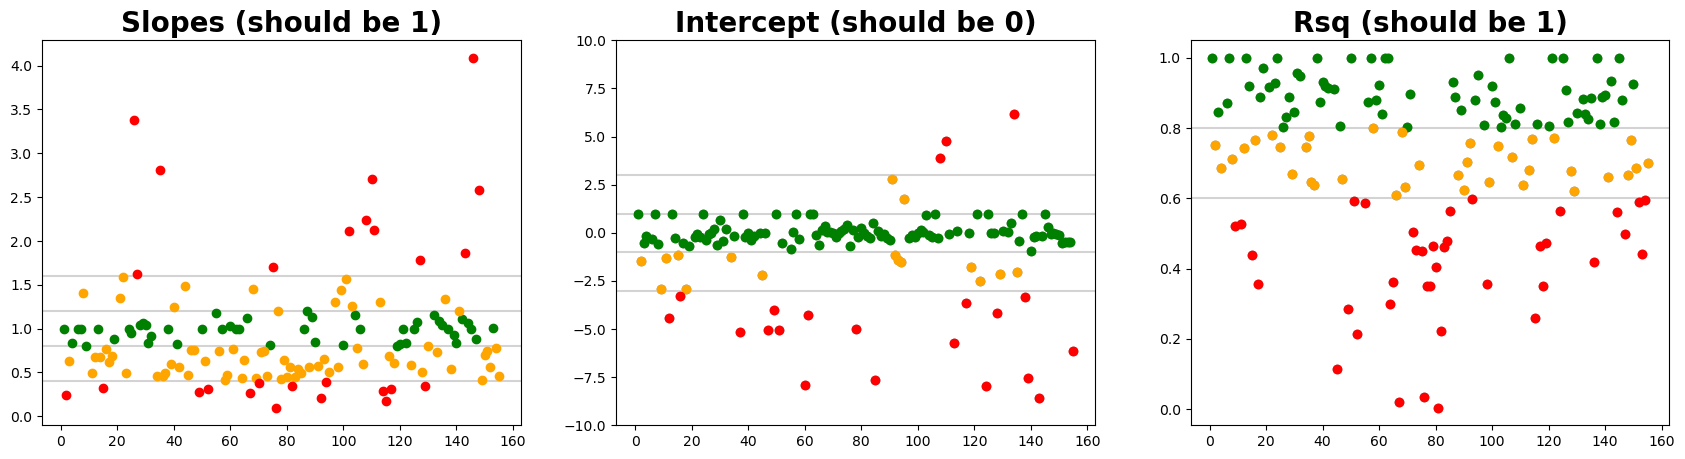

In [29]:
fig, ax = plt.subplots(1,3, figsize = (21,5))
ax[0].scatter(basin_nos[np.abs(slopes -1) <= 0.2], slopes[np.abs(slopes -1) <= 0.2], color = 'green', zorder = 10)
ax[0].scatter(basin_nos[(np.abs(slopes -1) <= 0.6) & (np.abs(slopes -1) > 0.2)], 
              slopes[(np.abs(slopes -1) <= 0.6) & (np.abs(slopes -1) > 0.2)], color = 'orange', zorder = 10)
ax[0].scatter(basin_nos[np.abs(slopes -1) > 0.6], slopes[np.abs(slopes -1) > 0.6], color = 'red', zorder = 10)

ax[1].scatter(basin_nos[np.abs(intercepts) <= 1], intercepts[np.abs(intercepts) <= 1], color = 'green', zorder = 10)
ax[1].scatter(basin_nos[(np.abs(intercepts) <= 3) & (np.abs(intercepts) > 1)], 
              intercepts[(np.abs(intercepts) <= 3) & (np.abs(intercepts) > 1)], color = 'orange', zorder = 10)
ax[1].scatter(basin_nos[np.abs(intercepts) > 3], intercepts[np.abs(intercepts) > 3], color = 'red', zorder = 10)

ax[1].scatter(basin_nos, intercepts, color = 'grey', zorder = 0)
ax[2].scatter(basin_nos, rsqs, color = 'grey', zorder = 10)
ax[2].scatter(basin_nos[rsqs >= 0.8], rsqs[rsqs >= 0.8], color = 'green', zorder = 10)
ax[2].scatter(basin_nos[(rsqs < 0.8) & (rsqs >= 0.6)], rsqs[(rsqs < 0.8) & (rsqs >0.6)], color = 'orange', zorder = 10)
ax[2].scatter(basin_nos[rsqs < 0.6], rsqs[rsqs < 0.6], color = 'red', zorder = 10)

ax[0].axhline(0.8, color = 'lightgrey')
ax[0].axhline(1.2, color = 'lightgrey')
ax[0].axhline(0.4, color = 'lightgrey')
ax[0].axhline(1.6, color = 'lightgrey')

ax[1].axhline(-1, color = 'lightgrey')
ax[1].axhline(1, color = 'lightgrey')
ax[1].axhline(-3, color = 'lightgrey')
ax[1].axhline(3, color = 'lightgrey')
ax[1].set_ylim(-10,10)

ax[2].axhline(0.8, color = 'lightgrey')
ax[2].axhline(0.6, color = 'lightgrey')

titles = ['Slopes (should be 1)', 'Intercept (should be 0)', 'Rsq (should be 1)']
for jj in range(3):
    ax[jj].set_title(titles[jj], fontsize = 20, fontweight = 'bold')


In [30]:
thresholds_slope = 0.2, 0.4 

In [31]:
i = 143

In [32]:
df_lat_lon = df_ref_pred.groupby(['lat','lon'],as_index = False).mean()

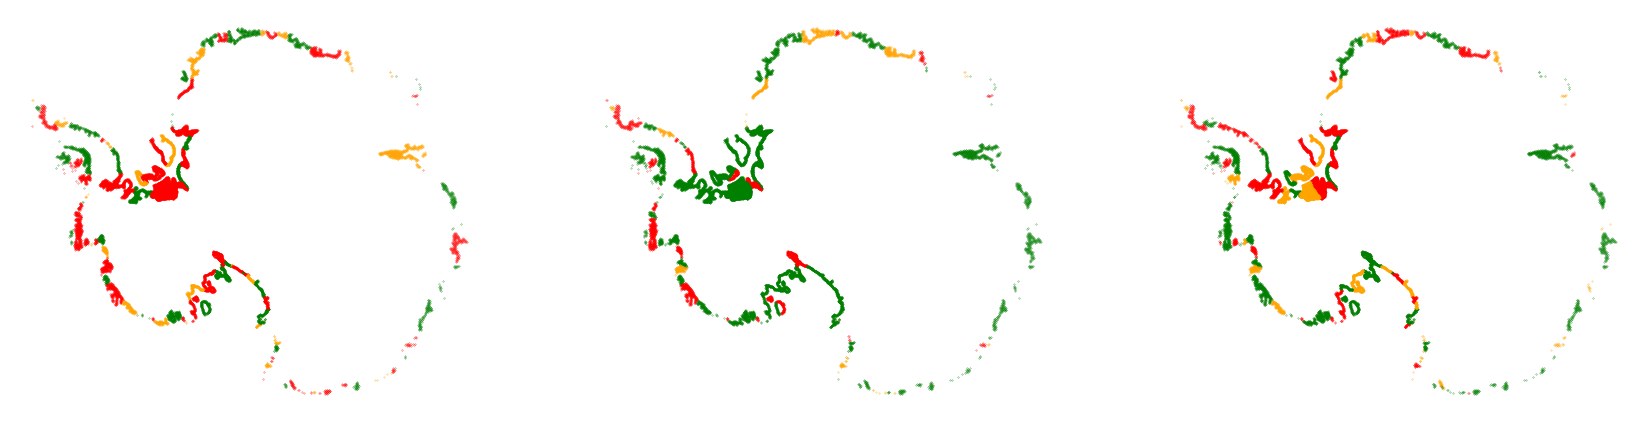

In [33]:
fig, ax = plt.subplots(1,3, figsize = (21,7), subplot_kw={'projection': proj})
for i in range(len(basin_nos)):
    print(basin_nos[i], end = '\r')
    df_lat_lon_basin = df_lat_lon[df_lat_lon.basin == basin_nos[i]]
    if rsqs[i] > 0.8:
        im = ax[2].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'green')
    elif rsqs[i] > 0.6:
        im = ax[2].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'orange')
    else:
        im = ax[2].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'red')

    if np.abs(intercepts[i]) <= 1:
        im = ax[1].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'green')
    elif np.abs(intercepts[i]) <= 3:
        im = ax[1].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'orange')
    else:
        im = ax[1].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'red')

    if np.abs(slopes[i] -1) <= 0.2:
        im = ax[0].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'green')
    elif np.abs(slopes[i]-1) <= 0.4:
        im = ax[0].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'orange')
    else:
        im = ax[0].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'red')
        
for jj in range(3):
    ax[jj].axis('off');

(-2741012.0626252694,
 3069564.888898648,
 -2403944.5608183914,
 2477753.7139694095)

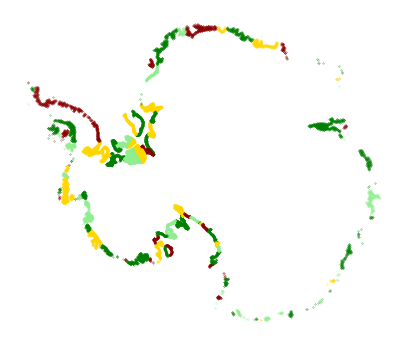

In [34]:
fig, ax = plt.subplots(1,1, figsize = (5,5), subplot_kw={'projection': proj})
for i in range(len(basin_nos)):
    print(basin_nos[i], end = '\r')
    df_lat_lon_basin = df_lat_lon[df_lat_lon.basin == basin_nos[i]]
    if (np.abs(slopes[i]-1) <= 0.4) & (np.abs(intercepts[i]) < 3) & (rsqs[i] > 0.6):
        im = plt.scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'green')
    elif ((np.abs(slopes[i]-1) <= 0.4) & (np.abs(intercepts[i]) < 3) & (rsqs[i] > 0.6)) or \
         ((np.abs(slopes[i]-1) <= 0.4) & (np.abs(intercepts[i]) > 3) & (rsqs[i] < 0.6)) or \
         ((np.abs(slopes[i]-1) > 0.4) & (np.abs(intercepts[i]) < 3) & (rsqs[i] > 0.6)):
        im = plt.scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'lightgreen')
    elif ((np.abs(slopes[i]-1) <= 0.4) & (np.abs(intercepts[i]) > 3) & (rsqs[i] < 0.6)) or \
         ((np.abs(slopes[i]-1) > 0.4) & (np.abs(intercepts[i]) < 3) & (rsqs[i] < 0.6)) or \
         ((np.abs(slopes[i]-1) > 0.4) & (np.abs(intercepts[i]) > 3) & (rsqs[i] > 0.6)):
        im = plt.scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'gold')
    else:
        im = plt.scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'darkred')
ax.axis('off')

In [35]:
i = 125
just_basin_ym = df_ymb[df_ymb.basin == i]

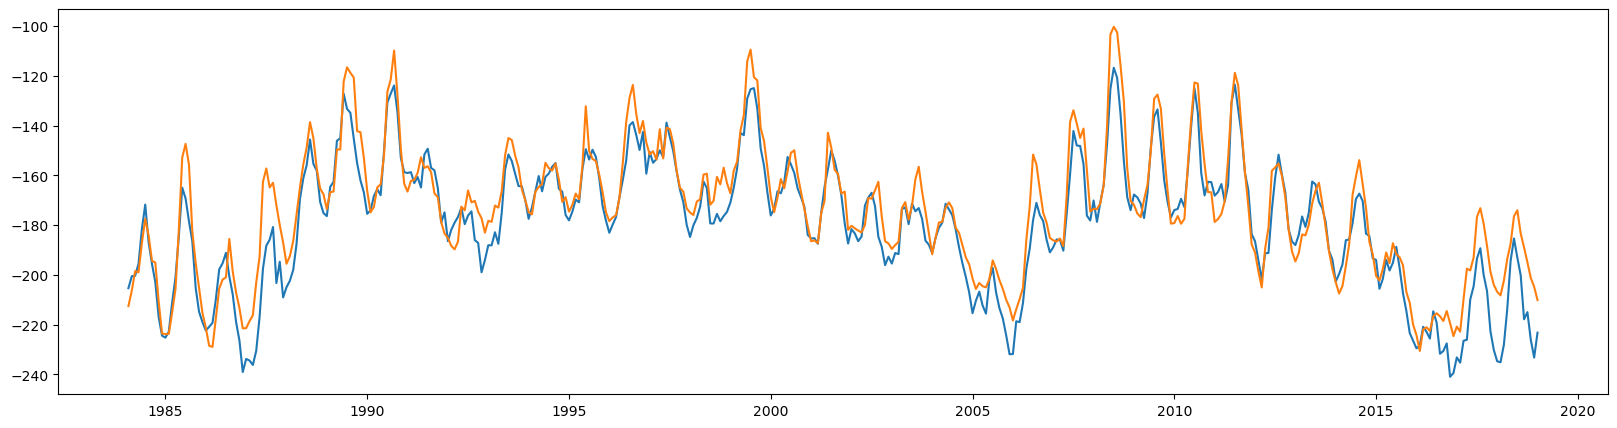

In [36]:
fig, ax = plt.subplots(1,1,figsize = (20,5))
plt.plot(just_basin_ym.year + just_basin_ym.month/12, just_basin_ym.melt_Gt_per_y)
plt.plot(just_basin_ym.year + just_basin_ym.month/12, just_basin_ym.melt_pred_Gt)

In [55]:
df_ymb

,year,month,basin,lat,lon,area,melt_m_ice_per_y,melt_01,melt_02,melt_03,melt_04,melt_05,melt_06,melt_07,melt_08,melt_09,melt_10,melt_pred_mean,melt_Gt_per_y,melt_pred_Gt
0,1984,1,1.0,-26401.755918,-17928.232971,6.988245e+09,-0.020307,-0.006429,-0.004906,-0.015503,0.000209,-0.007677,-0.012372,0.000702,-0.003695,-0.014103,-0.009840,-0.007361,-12.948322,-4.693960
1,1984,1,2.0,-10483.899519,-2979.651835,6.823856e+09,-0.001939,-0.001311,-0.002151,-0.001707,-0.001276,-0.001368,-0.001801,-0.001713,-0.001885,-0.000876,-0.001813,-0.001590,-2.967853,-2.454128
2,1984,1,3.0,-19566.225809,-3956.119825,1.742838e+10,-0.006361,-0.007211,-0.007534,-0.008499,-0.008387,-0.007319,-0.006630,-0.007539,-0.007746,-0.007470,-0.007418,-0.007575,-13.248093,-16.132951
3,1984,1,4.0,-1624.895160,-155.853593,1.925399e+09,-0.000982,-0.001101,-0.001067,-0.001086,-0.001208,-0.001094,-0.001146,-0.001128,-0.001160,-0.001014,-0.001176,-0.001118,-2.617669,-2.970298
4,1984,1,6.0,-1924.028442,-293.920725,2.123506e+09,-0.000814,-0.001644,-0.001736,-0.002341,-0.001645,-0.001775,-0.001736,-0.001561,-0.001615,-0.001611,-0.001812,-0.001748,-2.044180,-4.372189
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59635,2018,12,151.0,-26150.632487,-15232.426324,9.719307e+09,-0.004384,0.010348,0.006061,0.001487,0.005338,-0.000983,0.002987,0.005941,0.006016,0.003860,0.003291,0.004435,-3.661403,4.354298
59636,2018,12,152.0,-20439.025627,-13213.938504,8.373084e+09,-0.006240,0.000537,0.000474,0.000252,0.001978,0.001463,-0.000588,0.000587,0.003737,-0.000093,-0.002096,0.000625,-6.552815,0.423947
59637,2018,12,153.0,-5338.933413,-1481.342548,4.126381e+09,-0.001181,-0.001311,-0.000992,-0.001051,-0.001445,-0.001213,-0.000985,-0.001378,-0.001260,-0.001046,-0.000977,-0.001166,-2.129351,-2.128882
59638,2018,12,154.0,-1238.982225,1305.000000,1.813922e+09,-0.000237,-0.000244,-0.000177,-0.000163,-0.000162,-0.000327,-0.000269,-0.000209,-0.000145,-0.000130,-0.000236,-0.000206,-0.753846,-0.657128


In [ ]:
kg/m2/s -> kg/m2/yr * m3/kg -> m/yr 

In [80]:
(df_yb[mask].melt_Gt_per_y.values - df_yb[mask].melt_pred_Gt.values)/917)**2

SyntaxError: unmatched ')' (272446911.py, line 1)

In [81]:
diffs = np.ones(len(basin_nos))
percents = np.ones(len(basin_nos))
for i in range(len(basin_nos)):
    mask = (df_ymb.basin == basin_nos[i])
    diffs[i] = np.mean(df_ymb[mask].melt_Gt_per_y - df_ymb[mask].melt_pred_Gt)
    diffs[i] = np.sqrt(np.mean(((df_yb[mask].melt_Gt_per_y.values - df_yb[mask].melt_pred_Gt.values)/917)**2))
    percents[i] = np.mean((df_ymb[mask].melt_Gt_per_y - df_ymb[mask].melt_pred_Gt)*100/df_ymb[mask].melt_pred_Gt)

/tmp/ipykernel_1429357/1632355353.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  diffs[i] = np.sqrt(np.mean(((df_yb[mask].melt_Gt_per_y.values - df_yb[mask].melt_pred_Gt.values)/917)**2))
/tmp/ipykernel_1429357/1632355353.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  diffs[i] = np.sqrt(np.mean(((df_yb[mask].melt_Gt_per_y.values - df_yb[mask].melt_pred_Gt.values)/917)**2))
/tmp/ipykernel_1429357/1632355353.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  diffs[i] = np.sqrt(np.mean(((df_yb[mask].melt_Gt_per_y.values - df_yb[mask].melt_pred_Gt.values)/917)**2))
/tmp/ipykernel_1429357/1632355353.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  diffs[i] = np.sqrt(np.mean(((df_yb[mask].melt_Gt_per_y.values - df_yb[mask].melt_pred_Gt.values)/917)**2))
/tmp/ipykernel_1429357/1632355353.py:6: UserWarning: Boolean Series key will be reindexed to match D

In [38]:
i = 99
mask = (df_ymb.basin == 98)
df_spec_b = df_ymb[mask].groupby(['year', 'month'], as_index = False).sum()

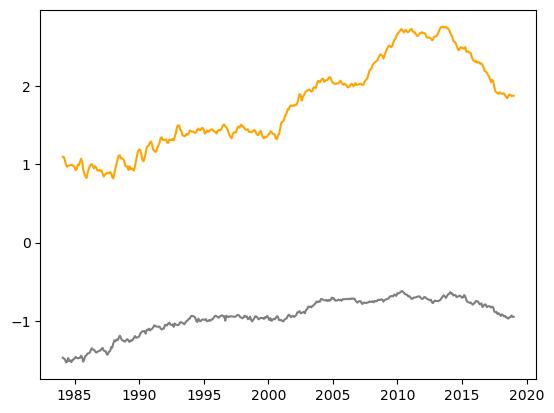

In [39]:
plt.plot(df_spec_b.year + df_spec_b.month/12, df_spec_b.melt_pred_Gt, color = 'orange')
plt.plot(df_spec_b.year + df_spec_b.month/12, df_spec_b.melt_Gt_per_y, color = 'grey')

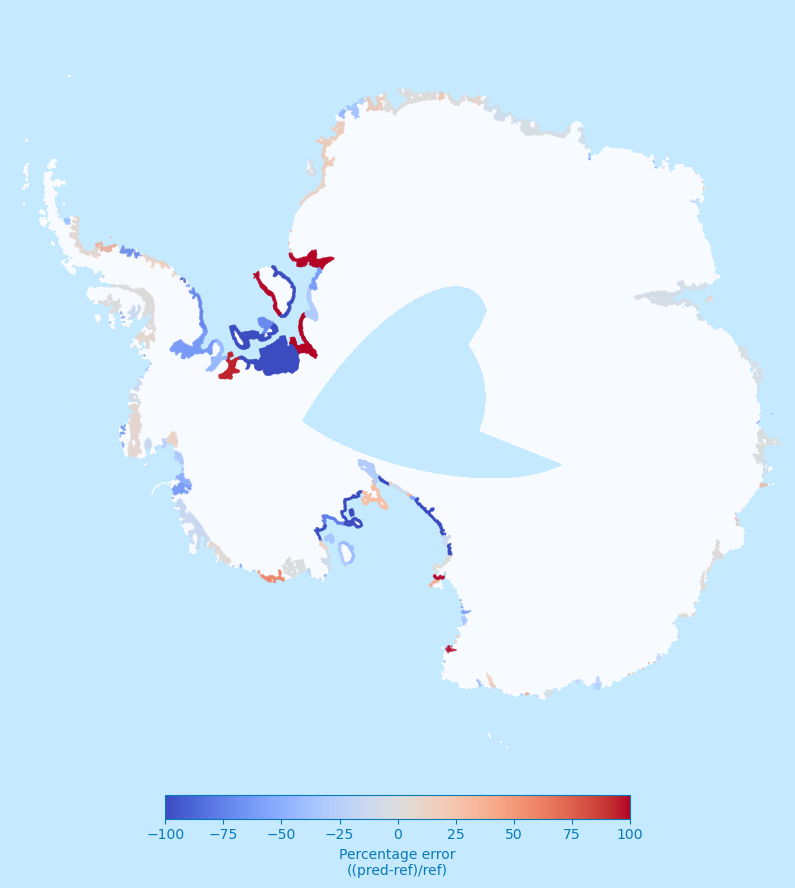

In [51]:
with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white'}):
    fig, ax = plt.subplots(1,1, figsize = (20,12), subplot_kw={'projection': proj})
    dsREF=xr.open_dataset('../MASKS_PARAM/domain_cfg_eANT025.L121.nc')
    dsREF = dsREF.squeeze('time_counter')
    ocean2=xr.where(((dsREF.top_level<0.5)&(dsREF.top_level<1.5)),1,np.nan)
    lon2d=dsREF.glamt.values
    lat2d=dsREF.gphit.values
    # to avoid hexagons in cartopy:
    lon2d[lon2d>=180] = lon2d[lon2d>=180.] - 360.
    delta_lon=np.abs(np.diff(lon2d))
    for i, start in enumerate(np.argmax(delta_lon > 180, axis=1)):
       lon2d[i, start+1:] += 360
    ax.set_extent( (-180, 180, -88, -65), trans )
    im = ax.pcolormesh(lon2d,lat2d,ocean2, vmin = -0.1, vmax = 0.9, rasterized=False, cmap = 'Blues_r', transform=trans, alpha = 1)
    
    for i in range(len(basin_nos)):
        mask = (latlonbasin.basin == basin_nos[i])
        im = plt.scatter(latlonbasin[mask].lon, latlonbasin[mask].lat, c = np.ones(len(latlonbasin[mask])) * percents[i], \
                         transform = trans, s = 0.1, cmap = 'coolwarm')
        im.set_clim(-100,100)
    ax.axis('off')
    cbar = plt.colorbar(orientation = 'horizontal', shrink = 0.3, pad = 0.01)
    cbar.set_label('Percentage error\n((pred-ref)/ref)')

fig.savefig('FIGURES/Percents.png', dpi = 200, bbox_inches = 'tight')

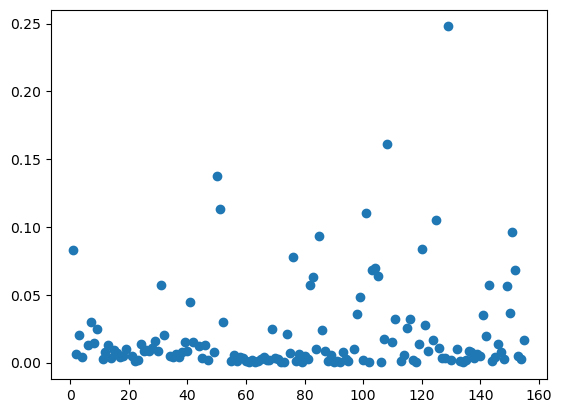

In [82]:
plt.scatter(basin_nos, diffs)

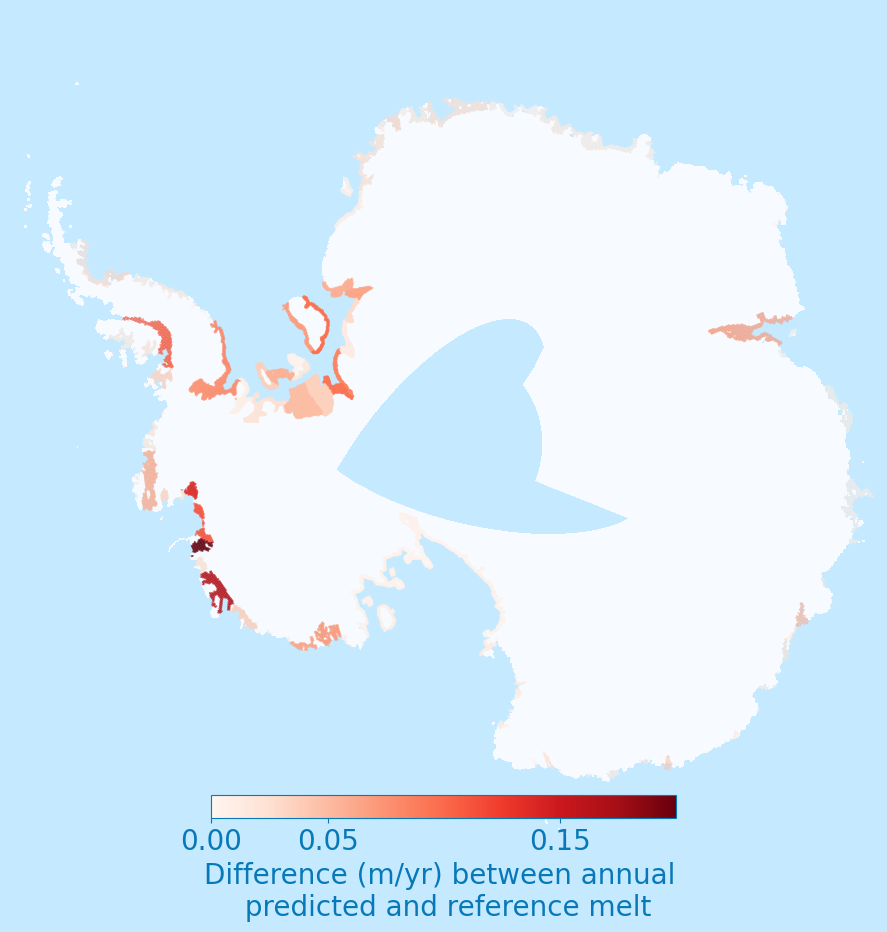

In [85]:
with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white', 'font.size' : 20}):
    fig, ax = plt.subplots(1,1, figsize = (20,12), subplot_kw={'projection': proj})
    dsREF=xr.open_dataset('../MASKS_PARAM/domain_cfg_eANT025.L121.nc')
    dsREF = dsREF.squeeze('time_counter')
    ocean2=xr.where(((dsREF.top_level<0.5)&(dsREF.top_level<1.5)),1,np.nan)
    lon2d=dsREF.glamt.values
    lat2d=dsREF.gphit.values
    # to avoid hexagons in cartopy:
    lon2d[lon2d>=180] = lon2d[lon2d>=180.] - 360.
    delta_lon=np.abs(np.diff(lon2d))
    for i, start in enumerate(np.argmax(delta_lon > 180, axis=1)):
       lon2d[i, start+1:] += 360
    ax.set_extent( (-180, 180, -88, -65), trans )
    im = ax.pcolormesh(lon2d,lat2d,ocean2, vmin = -0.1, vmax = 0.9, rasterized=False, cmap = 'Blues_r', transform=trans, alpha = 1)
    
    for i in range(len(basin_nos)):
        mask = (latlonbasin.basin == basin_nos[i])
        im = plt.scatter(latlonbasin[mask].lon, latlonbasin[mask].lat, c = np.ones(len(latlonbasin[mask])) * diffs[i], \
                         transform = trans, s = 0.1, cmap = 'Reds')
        im.set_clim(0,0.2)
    ax.axis('off')
    cbar = plt.colorbar(orientation = 'horizontal', shrink = 0.3, pad = -0.09)
    cbar.set_label('Difference (m/yr) between annual \n predicted and reference melt')
    cbar.set_ticks((0.0,0.05,0.15))

fig.savefig('FIGURES/Difference.png', dpi = 200, bbox_inches = 'tight')

In [49]:
latlonbasin = df_ref_pred.groupby(['lat','lon'], as_index = False).mean()

latlonbasin_m = latlonbasin.groupby('basin', as_index = False).mean()
latlonbasin_m = latlonbasin_m.drop(['area','year','month', 'melt_m_ice_per_y', 'melt_01', 'melt_02', 'melt_03', 'melt_04', 'melt_05', 'melt_06',\
                   'melt_07', 'melt_08', 'melt_09', 'melt_10', 'melt_pred_mean', 'melt_Gt_per_y', 'melt_pred_Gt'], axis = 1)
latlonbasin_m

,basin,lat,lon
0,1.0,-82.764125,-56.201357
1,2.0,-75.423738,-21.436344
2,3.0,-73.008305,-14.761641
3,4.0,-70.647616,-6.776243
4,6.0,-71.260313,-10.885953
...,...,...,...
137,151.0,-79.971353,-46.582343
138,152.0,-79.221030,-51.216816
139,153.0,-74.151853,-20.574202
140,154.0,-68.811594,72.428571


In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
#plt.scatter(latlonbasin_m.lon,latlonbasin_m.lat, transform = trans)
i = 1
mask = [latlonbasin_m.basin.values == i][0]
plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = 'red')

colors = ['deeppink', 'tomato', 'firebrick', 'darkorange']
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]
for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = plt.scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                   transform = trans, s= 0.1)        

In [ ]:
bym = df_ref_pred.groupby(['basin', 'year','month'], as_index = False).sum()
mean_diff = np.ones(18)
mean_diffm = np.ones(18)
mean_percent = np.ones(18)
mean_percentm = np.ones(18)
for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    difference = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)
    percent = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)*100/bym2.melt_Gt_per_y
    mean_diff[i] = (np.mean(difference))
    mean_percent[i] = (np.max(np.abs(percent)))
    mask = np.in1d(bym.basin, regions[i])
    bym3 = bym[mask].groupby(['year','month'], as_index = False).sum()
    difference = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)
    percent = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)*100/bym3.melt_Gt_per_y
    mean_diffm[i] = (np.mean(difference))
    mean_percentm[i] = (np.max(np.abs(percent)))

In [ ]:
#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'axes.titlecolor':'#0879B8'}):
with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white'}):
    ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
    fig = plt.figure(constrained_layout=True, figsize = (20,18))
    widths = [4,4,4,4,4,4]
    heights = [4,4,4,4,4]
    gs = fig.add_gridspec(5,6, width_ratios = widths, height_ratios = heights)
    #for i,j in itertools.product(range(5),range(6)):
    #    fig.add_subplot(gs[i,j])
    
    
    titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
              'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
              'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
              'Ipp-J', 'J-Jpp', 'Jpp-K']
    coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
              (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
              (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
              (0.3,0.49), (0.4,0.60)]
    
    ax[17] = fig.add_subplot(gs[1:4,1:5], projection= proj)
    ax[17].set_extent( (-180, 180, -88, -65), trans )
    im = ax[17].pcolormesh(lon2d,lat2d,ocean2, vmin = -0.1, vmax = 0.9, rasterized=False, cmap = 'Blues_r', transform=trans, alpha = 1)
    
    
    for i in range(len(regions)):
        for j in range(len(regions[i])):
            #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
            #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
            basin = latlonbasin[latlonbasin.basin == regions[i][j]]
            im = ax[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                       transform = trans, s= 1)    
        ax[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                       fontsize = 20, color = colors[np.mod(i,4)])
    
    ax[17].axis('off')
    
    
    plot_i = [0,0,0,1,2,3,4,4,4,4,4,4,3,2,1,0,0,0]
    plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
    for i in range(18):
        ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])
    
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        ax[i].plot(bym2.year, bym2.melt_Gt_per_y, color = 'lightgrey')
        ax[i].plot(bym2.year, bym2.melt_pred_Gt, color = colors[np.mod(i,4)])
        ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold')
        ax[i].tick_params(axis='both', which='major', labelsize=14)
        #ax[i].plot(bym2.year, bym2.melt_Gt_per_y-  bym2.melt_pred_Gt, color = colors[np.mod(i,5)])        

fig.savefig('FIGURES/Basin_melt.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (20,18))
widths = [4,4,4,4,4,4]
heights = [4,4,4,4,4]
gs = fig.add_gridspec(5,6, width_ratios = widths, height_ratios = heights)
#for i,j in itertools.product(range(5),range(6)):
#    fig.add_subplot(gs[i,j])

titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
          'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
          'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
          'Ipp-J', 'J-Jpp', 'Jpp-K']
coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
          (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
          (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
          (0.3,0.52), (0.4,0.60)]

ax[17] = fig.add_subplot(gs[1:4,1:5], projection= proj)

for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = ax[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,5)], \
                   transform = trans, s= 1)    
    ax[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                   fontsize = 20, color = colors[np.mod(i,5)])
ax[17].axis('off')


plot_i = [0,0,0,1,2,3,4,4,4,4,4,4,3,2,1,0,0,0]
plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
for i in range(18):
    ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    ax[i].plot(bym2.year, bym2.melt_Gt_per_y, color = 'grey')
    ax[i].plot(bym2.year, bym2.melt_pred_Gt, color = colors[np.mod(i,5)])
    ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold')
    ax[i].tick_params(axis='both', which='major', labelsize=14)
    #ax[i].plot(bym2.year, bym2.melt_Gt_per_y-  bym2.melt_pred_Gt, color = colors[np.mod(i,5)])        


In [11]:
# Look at the annual data 
def annual_comp(this_collection, exp_name, keep_all_runs = True, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, 
                   apply_collection = None):
    ref_pred = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset')
    ref_pred_annual = load_results_nn(this_collection, exp_name, verbose, annual_only = 'True', apply_collection = 'whole_dataset')
    ref_pred_af = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset', \
                                   annual_f = 'annual_')
    ref_pred_annual_af = load_results_nn(this_collection, exp_name, verbose, annual_only = 'True', apply_collection = 'whole_dataset', \
                                             annual_f = 'annual_')
    tmay = ref_pred_annual.groupby(['year'], as_index = False).sum()
    ref_pred_monthly = ref_pred.groupby(['lat','lon','year'], as_index = False).mean()
    tmam = ref_pred_monthly.groupby(['year'], as_index = False).sum()
    tyay = ref_pred_annual_af.groupby(['year'], as_index = False).sum()
    ref_pred_monthly = ref_pred_af.groupby(['lat','lon','year'], as_index = False).mean()
    tyam = ref_pred_monthly.groupby(['year'], as_index = False).sum()
    # Train month apply year
    # Train month apply month
    # Train year apply year
    # Train year apply month
    return tmay, tmam, tyay, tyam  

In [12]:
this_collection = 'no_jun_dec'
exp_name = 'slope_front'
tmay, tmam, tyay, tyam = annual_comp(this_collection, exp_name, verbose = 1, apply_collection = None)
this_collection = 'no_mar_oct'
exp_name = 'slope_front'
tmay2, tmam2, tyay2, tyam2 = annual_comp(this_collection, exp_name, verbose = 1, apply_collection = None)

In [13]:
this_collection = 'no_middle_5'
exp_name = 'slope_front'
tmay3, tmam3, tyay3, tyam3 = annual_comp(this_collection, exp_name, verbose = 1, apply_collection = None)

In [14]:
this_collection = 'up_to_2018'
exp_name = 'slope_front'
tmay4, tmam4, tyay4, tyam4 = annual_comp(this_collection, exp_name, verbose = 1, apply_collection = None)
this_collection = 'after_1984'
exp_name = 'slope_front'
tmay5, tmam5, tyay5, tyam5 = annual_comp(this_collection, exp_name, verbose = 1, apply_collection = None)

In [15]:
all_data = load_test_data('whole_dataset', verbose = 0)

You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv
You have kept the whole dataset


In [16]:
tyams = (np.mean(tyam.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyam2.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyam3.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyam4.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyam5.melt_pred_Gt*100/tmay.melt_Gt_per_y))
tyays = (np.mean(tyay.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyay2.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyay3.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyay4.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyay5.melt_pred_Gt*100/tmay.melt_Gt_per_y))
tmams = (np.mean(tmam.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmam2.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmam3.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmam4.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmam5.melt_pred_Gt*100/tmay.melt_Gt_per_y))
tmays = (np.mean(tmay.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmay2.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmay3.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmay4.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmay5.melt_pred_Gt*100/tmay.melt_Gt_per_y))

In [17]:
tyams, tyays, tmams, tmays

((100.94556692719836,
  99.6458455069855,
  100.54528663340245,
  100.42224350833894,
  99.23402900793798),
 (98.91552200531352,
  97.52726783810041,
  98.30910101606366,
  98.30676387526645,
  97.13393844201131),
 (100.90385291573546,
  99.69083148639469,
  100.55147594831472,
  100.4833465271695,
  99.1962262565995),
 (98.86672301148437,
  97.41880581837415,
  98.4979237417836,
  98.34530138534461,
  97.23397782358556))

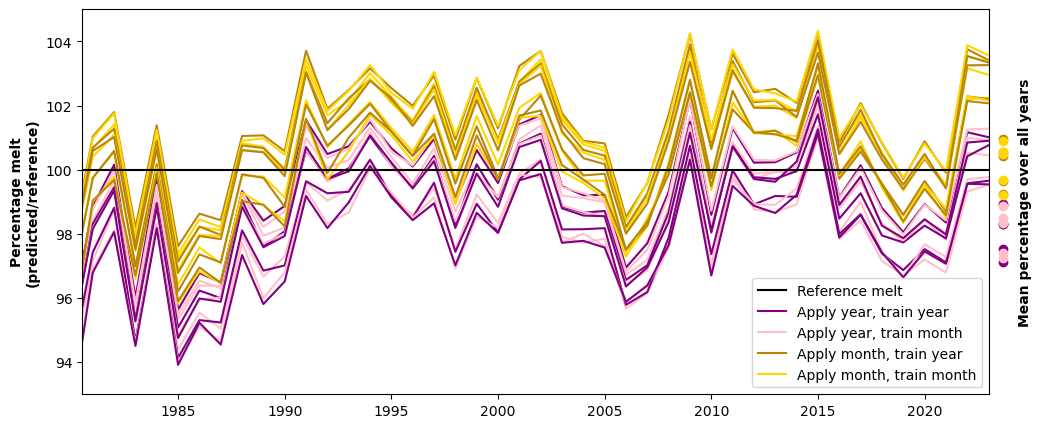

In [18]:
widths = (12,0.25)
fig, ax = plt.subplots(1,2, figsize = (12,5), width_ratios = widths)
ax[0].plot(tmay.year, tmay.melt_Gt_per_y*100/tmay.melt_Gt_per_y , c = 'k', label = 'Reference melt', zorder = 10)
ax[0].plot(tyay.year, tyay.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'purple', label = 'Apply year, train year')
ax[0].plot(tmay.year, tmay.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'pink', label = 'Apply year, train month')
ax[0].plot(tyam.year, tyam.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'darkgoldenrod', label = 'Apply month, train year')
ax[0].plot(tmam.year, tmam.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'gold', label = 'Apply month, train month')
ax[0].plot(tmay2.year, tmay2.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'pink')#, label = 'Train month, Apply year')
ax[0].plot(tyay2.year, tyay2.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'purple')#, label = 'Train year, Apply year')
ax[0].plot(tmam2.year, tmam2.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'gold')#, label = 'Train month, Apply month')
ax[0].plot(tyam2.year, tyam2.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'darkgoldenrod')#, label = 'Train year, apply month')
ax[0].plot(tmay3.year, tmay3.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'pink')#, label = 'Train month, Apply year')
ax[0].plot(tyay3.year, tyay3.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'purple')#, label = 'Train year, Apply year')
ax[0].plot(tmam3.year, tmam3.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'gold')#, label = 'Train month, Apply month')
ax[0].plot(tyam3.year, tyam3.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'darkgoldenrod')#, label = 'Train year, apply month')
ax[0].plot(tmay4.year, tmay4.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'pink')#, label = 'Train month, Apply year')
ax[0].plot(tyay4.year, tyay4.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'purple')#, label = 'Train year, Apply year')
ax[0].plot(tmam4.year, tmam4.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'gold')#, label = 'Train month, Apply month')
ax[0].plot(tyam4.year, tyam4.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'darkgoldenrod')#, label = 'Train year, apply month')
ax[0].plot(tmay5.year, tmay5.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'pink')#, label = 'Train month, Apply year')
ax[0].plot(tyay5.year, tyay5.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'purple')#, label = 'Train year, Apply year')
ax[0].plot(tmam5.year, tmam5.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'gold')#, label = 'Train month, Apply month')
ax[0].plot(tyam5.year, tyam5.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'darkgoldenrod')#, label = 'Train year, apply month')
ax[0].legend()
ax[0].set_xlim(1980.5,2023)
ax[0].set_ylim(93,105)
ax[0].set_ylabel('Percentage melt\n(predicted/reference)', fontweight = 'bold')
ax[1].set_ylim(93,105)
ax[1].get_xaxis().set_ticks([]); ax[1].get_yaxis().set_ticks([]);
ax[1].scatter(np.ones(5),tyams, color  = 'darkgoldenrod')
ax[1].scatter(np.ones(5),tyays, color  = 'purple')
ax[1].scatter(np.ones(5),tmams, color  = 'gold')
ax[1].scatter(np.ones(5),tmays, color  = 'pink')
ax[1].set_frame_on(False)
ax[1].set_ylabel('Mean percentage over all years', fontweight = 'bold')
ax[1].yaxis.set_label_position("right")
plt.subplots_adjust(wspace = 0.01)

Text(0, 0.5, 'Integrated melt (Gt)')

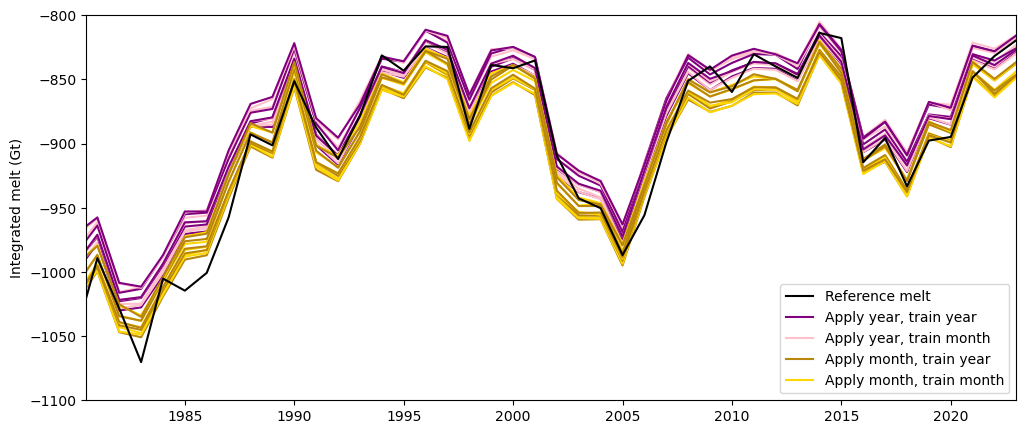

In [19]:
fig, ax = plt.subplots(1,1, figsize = (12,5))
plt.plot(tmay.year, tmay.melt_Gt_per_y, c = 'k', label = 'Reference melt', zorder = 20)
plt.plot(tyay.year, tyay.melt_pred_Gt, color = 'purple', label = 'Apply year, train year')
plt.plot(tmay.year, tmay.melt_pred_Gt, color = 'pink', label = 'Apply year, train month')
plt.plot(tyam.year, tyam.melt_pred_Gt, color = 'darkgoldenrod', label = 'Apply month, train year')
plt.plot(tmam.year, tmam.melt_pred_Gt, color = 'gold', label = 'Apply month, train month')
plt.plot(tmay2.year, tmay2.melt_pred_Gt, color = 'pink')#, label = 'Train month, Apply year')
plt.plot(tyay2.year, tyay2.melt_pred_Gt, color = 'purple')#, label = 'Train year, Apply year')
plt.plot(tmam2.year, tmam2.melt_pred_Gt, color = 'gold')#, label = 'Train month, Apply month')
plt.plot(tyam2.year, tyam2.melt_pred_Gt, color = 'darkgoldenrod')#, label = 'Train year, apply month')
plt.plot(tmay3.year, tmay3.melt_pred_Gt, color = 'pink')#, label = 'Train month, Apply year')
plt.plot(tyay3.year, tyay3.melt_pred_Gt, color = 'purple')#, label = 'Train year, Apply year')
plt.plot(tmam3.year, tmam3.melt_pred_Gt, color = 'gold')#, label = 'Train month, Apply month')
plt.plot(tyam3.year, tyam3.melt_pred_Gt, color = 'darkgoldenrod')#, label = 'Train year, apply month')
plt.plot(tmay4.year, tmay4.melt_pred_Gt, color = 'pink')#, label = 'Train month, Apply year')
plt.plot(tyay4.year, tyay4.melt_pred_Gt, color = 'purple')#, label = 'Train year, Apply year')
plt.plot(tmam4.year, tmam4.melt_pred_Gt, color = 'gold')#, label = 'Train month, Apply month')
plt.plot(tyam4.year, tyam4.melt_pred_Gt, color = 'darkgoldenrod')#, label = 'Train year, apply month')
plt.plot(tmay5.year, tmay5.melt_pred_Gt, color = 'pink')#, label = 'Train month, Apply year')
plt.plot(tyay5.year, tyay5.melt_pred_Gt, color = 'purple')#, label = 'Train year, Apply year')
plt.plot(tmam5.year, tmam5.melt_pred_Gt, color = 'gold')#, label = 'Train month, Apply month')
plt.plot(tyam5.year, tyam5.melt_pred_Gt, color = 'darkgoldenrod')#, label = 'Train year, apply month')
plt.legend()
plt.xlim(1980.5,2023)
plt.ylim(-1100,-800)
plt.ylabel('Integrated melt (Gt)')

Text(0, 0.5, 'Integrated melt (Gt)')

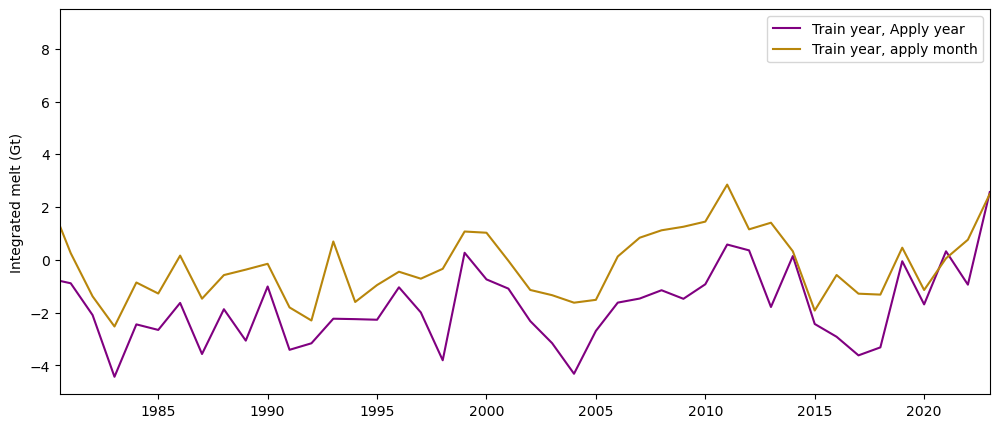

In [20]:
fig, ax = plt.subplots(1,1, figsize = (12,5))
#plt.plot(tmay.year, tmay.melt_Gt_per_y, c = 'grey', label = 'Reference melt')
#plt.plot(tmay.year, tmay.melt_pred_Gt, color = 'pink', label = 'Train month, Apply year')
#plt.plot(tmam.year, tmam.melt_pred_Gt, color = 'purple', label = 'Train month, Apply month')
#plt.plot(tyay.year, tyay.melt_pred_Gt, color = 'gold', label = 'Train year, Apply year')
#plt.plot(tyam.year, tyam.melt_pred_Gt, color = 'darkgoldenrod', label = 'Train year, Apply month')
plt.plot(tmay3.year, tmay3.melt_pred_Gt- tyay3.melt_pred_Gt, color = 'purple', label = 'Train year, Apply year')
plt.plot(tmam3.year, tmam3.melt_pred_Gt-tyam3.melt_pred_Gt, color = 'darkgoldenrod', label = 'Train year, apply month')
plt.legend()
plt.xlim(1980.5,2023)
#plt.ylim(-1100,-800)
plt.ylabel('Integrated melt (Gt)')

In [21]:
# Looking at the difference between annual and monthly melt by ice shelf 

In [22]:
this_collection = 'no_middle_5'
exp_name = 'slope_front'
verbose = 1
ref_pred1 = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset')
ref_pred = ref_pred1[ref_pred1.year > 1982]
ref_pred1 = None
ref_pred2 = load_results_nn(this_collection, exp_name, verbose, annual_only = 'True', apply_collection = 'whole_dataset')
ref_pred_2 = ref_pred2[ref_pred2.year > 1982]
ref_pred3 = load_results_nn(this_collection, exp_name, verbose, annual_f = 'annual_', apply_collection = 'whole_dataset')
ref_pred_3 = ref_pred3[ref_pred3.year > 1982]
ref_pred4 = load_results_nn(this_collection, exp_name, verbose, annual_f = 'annual_', annual_only = 'True', \
                            apply_collection = 'whole_dataset')
ref_pred_4 = ref_pred4[ref_pred4.year > 1982]

In [23]:
# 42 is good 
# Weirdly uniform 98, 99, 102, 115, 120, 121, 138, 148, 149, 150, 155
# Extremely good 101,113
# The same as overall pattern 104, 105, 107, 154
# Opposite pattern 117, 118, 130
# All agree but all miles off 127, 133
# Bad 151

In [24]:
basin_chosen = 104

ref_pred_basin = ref_pred[ref_pred.basin == basin_chosen]
ref_pred_basin1 = ref_pred_basin.groupby(['year','month','basin'], as_index = False).sum()
tmam = ref_pred_basin1.groupby('year', as_index = False).mean()
ref_pred2_sel = ref_pred_2[ref_pred_2.basin == basin_chosen]
ref_pred2_sel2 = ref_pred2_sel.groupby(['year','month','basin'], as_index = False).sum()
tmay = ref_pred2_sel2.groupby('year', as_index = False).mean()
ref_pred3_sel = ref_pred_3[ref_pred_3.basin == basin_chosen]
ref_pred3_sel2 = ref_pred3_sel.groupby(['year','month','basin'], as_index = False).sum()
tyam = ref_pred3_sel2.groupby('year', as_index = False).mean()
ref_pred4_sel = ref_pred_4[ref_pred_4.basin == basin_chosen]
ref_pred4_sel2 = ref_pred4_sel.groupby(['year','month','basin'], as_index = False).sum()
tyay = ref_pred4_sel2.groupby('year', as_index = False).mean()

ref_mean = np.mean(tmam.melt_Gt_per_y)
tmam_mean = np.mean(tmam.melt_Gt_per_y)
tmay_mean = np.mean(tmay.melt_Gt_per_y)
tyam_mean = np.mean(tyam.melt_Gt_per_y)
tyay_mean = np.mean(tyay.melt_Gt_per_y)
lat_mean = np.mean(ref_pred_basin.lat)
lon_mean = np.mean(ref_pred_basin.lon)

basin_nos = np.unique(ref_pred.basin.values)

In [25]:
#plt.scatter(0,np.mean(tmam.melt_Gt_per_y), color = 'grey')
#plt.scatter(1,np.mean(tmam.melt_pred_Gt), color = 'gold')
#plt.scatter(2,np.mean(tmay.melt_pred_Gt), color = 'pink')
#plt.scatter(3,np.mean(tyam.melt_pred_Gt), color = 'darkgoldenrod')
#plt.scatter(4,np.mean(tyay.melt_pred_Gt), color = 'purple')
#print(np.mean(tmam.melt_pred_Gt)-np.mean(tmay.melt_pred_Gt))

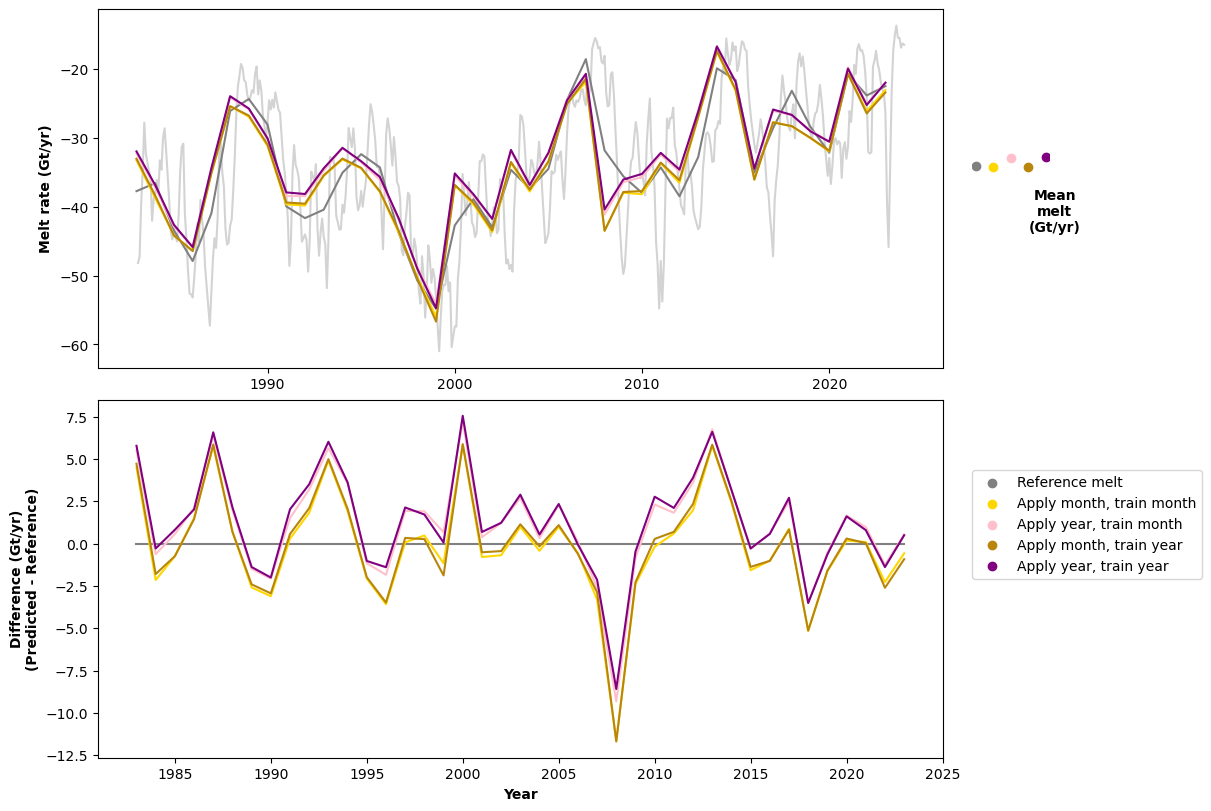

In [26]:
ax = [[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (12,8))
widths = [11,1]
heights = [4,4]
gs = fig.add_gridspec(2,2,width_ratios = widths, height_ratios = heights)
for i in range(2):
    ax[i] = fig.add_subplot(gs[i,0])
ax[2] = fig.add_subplot(gs[0,1])
ax[3] = fig.add_subplot(gs[1,1])

ax[0].plot(ref_pred_basin1.year+ref_pred_basin1.month*1/12, ref_pred_basin1.melt_Gt_per_y, color = 'lightgrey')
ax[0].plot(tmam.year, tmam.melt_Gt_per_y, color = 'grey')
ax[0].plot(tmam.year, tmam.melt_pred_Gt, color = 'gold', label = 'Apply month, Train month')
ax[0].plot(tmay.year, tmay.melt_pred_Gt, color = 'pink', label = 'Apply year, train month')
ax[0].plot(tyam.year, tyam.melt_pred_Gt, color = 'darkgoldenrod', label = 'Apply month, train year')
ax[0].plot(tyay.year, tyay.melt_pred_Gt, color = 'purple', label = 'Apply year, train year')
ax[0].set_ylabel('Melt rate (Gt/yr)', fontweight = 'bold')

ax[1].plot(tmam.year, tmam.melt_Gt_per_y-tmam.melt_Gt_per_y, color = 'grey')
ax[1].plot(tmam.year, tmam.melt_pred_Gt-tmam.melt_Gt_per_y, color = 'gold', label = 'Apply month, Train month')
ax[1].plot(tmay.year, tmay.melt_pred_Gt-tmam.melt_Gt_per_y, color = 'pink', label = 'Apply year, train month')
ax[1].plot(tyam.year, tyam.melt_pred_Gt-tmam.melt_Gt_per_y, color = 'darkgoldenrod', label = 'Apply month, train year')
ax[1].plot(tyay.year, tyay.melt_pred_Gt-tmam.melt_Gt_per_y, color = 'purple', label = 'Apply year, train year')
ax[1].set_xlabel('Year', fontweight = 'bold')
ax[1].set_ylabel('Difference (Gt/yr)\n(Predicted - Reference)', fontweight = 'bold')

#ax[1].legend(loc = (1.01,0))

ax[2].scatter(0,np.mean(tmam.melt_Gt_per_y), color = 'grey', label = 'Reference melt')
ax[2].scatter(1,np.mean(tmam.melt_pred_Gt), color = 'gold', label = 'Apply month, train month')
ax[2].scatter(2,np.mean(tmay.melt_pred_Gt), color = 'pink', label = 'Apply year, train month')
ax[2].scatter(3,np.mean(tyam.melt_pred_Gt), color = 'darkgoldenrod', label = 'Apply month, train year')
ax[2].scatter(4,np.mean(tyay.melt_pred_Gt), color = 'purple', label = 'Apply year, train year')

ax[3].scatter(0,np.mean(tmam.melt_Gt_per_y), color = 'grey', label = 'Reference melt')
ax[3].scatter(1,np.mean(tmam.melt_pred_Gt), color = 'gold', label = 'Apply month, train month')
ax[3].scatter(2,np.mean(tmay.melt_pred_Gt), color = 'pink', label = 'Apply year, train month')
ax[3].scatter(3,np.mean(tyam.melt_pred_Gt), color = 'darkgoldenrod', label = 'Apply month, train year')
ax[3].scatter(4,np.mean(tyay.melt_pred_Gt), color = 'purple', label = 'Apply year, train year')
ax[3].legend(loc = (0,0.5))
ax[3].set_xlim(10,15)
ax[3].axis('off')

ax[2].set_ylim(ax[0].get_ylim())
ax[2].set_ylabel('Mean\nmelt\n(Gt/yr)', fontweight = 'bold', rotation = 0)

ax[2].set_frame_on(False)
ax[2].yaxis.set_label_position("right")
ax[2].get_xaxis().set_ticks([]); ax[2].get_yaxis().set_ticks([]);

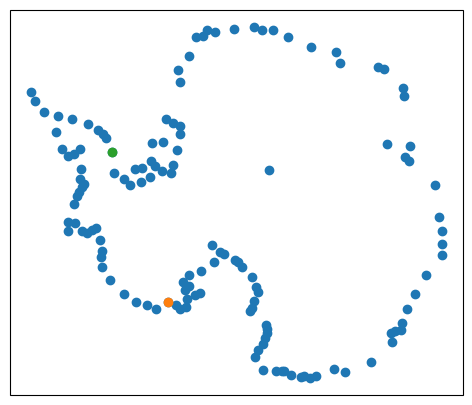

In [27]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
latlon = ref_pred_4.groupby(['basin'], as_index = False).mean()
plt.scatter(latlon.lon, latlon.lat, transform = trans)
plt.scatter(lon_mean, lat_mean, transform = trans)
plt.scatter(latlon.lon[104], latlon.lat[104], transform = trans)

In [28]:
ref_means = np.ones(len(basin_nos))
tmam_means = np.ones(len(basin_nos))
tmay_means = np.ones(len(basin_nos))
tyam_means = np.ones(len(basin_nos))
tyay_means = np.ones(len(basin_nos))
lat_means = np.ones(len(basin_nos))
lon_means = np.ones(len(basin_nos))
wavs = np.ones(len(basin_nos))

for i in range(len(basin_nos)):
    basin_chosen = basin_nos[i]

    ref_pred_basin = ref_pred[ref_pred.basin == basin_chosen]
    ref_pred_basin1 = ref_pred_basin.groupby(['year','month','basin'], as_index = False).sum()
    tmam = ref_pred_basin1.groupby('year', as_index = False).mean()
    ref_pred2_sel = ref_pred_2[ref_pred_2.basin == basin_chosen]
    ref_pred2_sel2 = ref_pred2_sel.groupby(['year','month','basin'], as_index = False).sum()
    tmay = ref_pred2_sel2.groupby('year', as_index = False).mean()
    ref_pred3_sel = ref_pred_3[ref_pred_3.basin == basin_chosen]
    ref_pred3_sel2 = ref_pred3_sel.groupby(['year','month','basin'], as_index = False).sum()
    tyam = ref_pred3_sel2.groupby('year', as_index = False).mean()
    ref_pred4_sel = ref_pred_4[ref_pred_4.basin == basin_chosen]
    ref_pred4_sel2 = ref_pred4_sel.groupby(['year','month','basin'], as_index = False).sum()
    tyay = ref_pred4_sel2.groupby('year', as_index = False).mean()
   
    # Calculate the ice shelf style
    ref_melt = ref_pred_basin.groupby(['year','month'], as_index = False).mean().melt_Gt_per_y.values
    zero = ref_melt - np.mean(ref_melt)
    grad = (zero[-1]- zero[0])/len(zero)
    slope = grad * np.arange(0,len(ref_melt),1)
    fft = np.abs(np.fft.fft(zero-slope-np.mean(zero-slope)))
    fft[0] = np.nan
    wav = np.abs(np.fft.fftfreq(len(ref_melt), 1/12))
    wavs[i] = 1/wav[np.nanargmax(fft)]

    ref_means[i] = np.mean(tmam.melt_Gt_per_y)
    tmam_means[i] = np.mean(tmam.melt_pred_Gt)
    tmay_means[i] = np.mean(tmay.melt_pred_Gt)
    tyam_means[i] = np.mean(tyam.melt_pred_Gt)
    tyay_means[i] = np.mean(tyay.melt_pred_Gt)
    lat_means[i] = np.mean(ref_pred_basin.lat)
    lon_means[i] = np.mean(ref_pred_basin.lon)


basin_nos = np.unique(ref_pred.basin.values)
areas = ref_pred.groupby(['year','month', 'basin'], as_index = False).sum().groupby('basin', as_index = False).mean().area
latlonbasin = ref_pred.groupby(['lat','lon'], as_index = False).mean()

In [29]:
all_data = load_test_data('whole_dataset', verbose = 1, keep_pandas = True)

You have loaded data to apply the nn to:
/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv
You have kept the whole dataset


In [30]:
#What do we want? 
#We want, by ice shelf, month, year the isdraft, the mean temperature/salinity, and mean distances?
#So, we can groupby basin, month, month? 
sorted_all = all_data.groupby(['year', 'month', 'basins_NEMO'], as_index = False).mean()
sorted_max = all_data.groupby(['year', 'month', 'basins_NEMO'], as_index = False).max()
sorted_useful = sorted_all.drop(['lat','lon','melt_m_ice_per_y', 'bathymetry','slope_is_lat', 'slope_is_lon',
                 'slope_ba_lat', 'slope_ba_lon', 'slope_is_across_front', 'slope_is_towards_front',\
                 'slope_ba_across_front', 'slope_ba_towards_front',\
                 'temperature_prop', 'salinity_prop', 'std_T', 'std_S'], axis = 1)
sorted_max_useful = sorted_max.drop(['lat','lon','melt_m_ice_per_y', 'bathymetry','slope_is_lat', 'slope_is_lon',
                 'slope_ba_lat', 'slope_ba_lon', 'slope_is_across_front', 'slope_is_towards_front',\
                 'slope_ba_across_front', 'slope_ba_towards_front',\
                 'temperature_prop', 'salinity_prop', 'std_T', 'std_S'], axis = 1)

In [31]:
sorted_basin = sorted_useful.groupby('basins_NEMO', as_index = False).mean()
sorted_basin_max = sorted_max_useful.groupby('basins_NEMO', as_index = False).mean()

In [32]:
sorted_basin

,basins_NEMO,year,month,distances_GL,distances_OO,distances_OC,corrected_isdraft,mean_T,mean_S,approx_area
0,1.0,2001.0,6.5,8464.339926,517259.242390,12307.334618,994.610646,-2.312562,34.677545,2.243759e+07
1,2.0,2001.0,6.5,12203.306057,98828.443514,13273.114207,230.854886,-1.906955,34.367622,4.910069e+07
2,3.0,2001.0,6.5,14907.620759,74748.659732,22750.379858,292.031944,-1.751913,34.398600,6.515577e+07
3,4.0,2001.0,6.5,15164.382868,20753.232848,21184.838375,206.398544,-1.804101,34.393013,8.362208e+07
4,6.0,2001.0,6.5,12716.237525,18124.356410,18233.387403,248.880235,-1.800588,34.429992,7.916559e+07
...,...,...,...,...,...,...,...,...,...,...
133,151.0,2001.0,6.5,9645.731092,214258.112450,10331.624146,664.885525,-2.245782,34.731465,2.970162e+07
134,152.0,2001.0,6.5,9835.823310,165027.811882,10130.895320,447.453712,-2.068197,34.791641,3.275129e+07
135,153.0,2001.0,6.5,14215.884888,35118.128885,12634.757964,220.899151,-1.838149,34.304491,5.730840e+07
136,154.0,2001.0,6.5,20283.288972,22838.054195,11168.216516,204.213531,-1.781243,34.414980,1.007734e+08


In [33]:
latlonbasin_m = latlonbasin.groupby('basin', as_index = False).mean()
latlonbasin_m = latlonbasin_m.drop(['area','year','month', 'melt_m_ice_per_y', 'melt_01', 'melt_02', 'melt_03', 'melt_04', 'melt_05', 'melt_06',\
                   'melt_07', 'melt_08', 'melt_09', 'melt_10', 'melt_pred_mean', 'melt_Gt_per_y', 'melt_pred_Gt'], axis = 1)
latlonbasin_m

,basin,lat,lon
0,1.0,-82.499408,-55.174075
1,2.0,-75.426981,-21.591176
2,3.0,-72.991423,-14.742699
3,4.0,-70.657999,-6.811745
4,6.0,-71.199622,-10.863597
...,...,...,...
133,151.0,-79.976483,-46.421865
134,152.0,-79.149134,-51.259408
135,153.0,-74.151903,-20.554153
136,154.0,-68.811594,72.428571


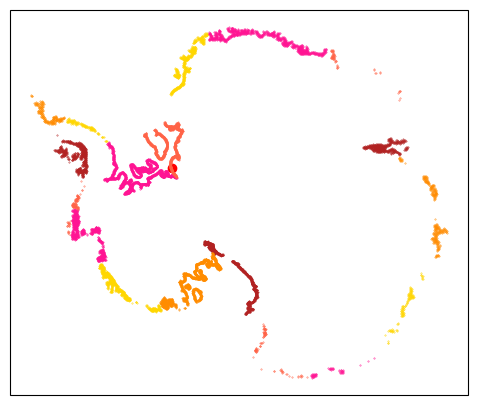

In [34]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
#plt.scatter(latlonbasin_m.lon,latlonbasin_m.lat, transform = trans)
i = 1
mask = [latlonbasin_m.basin.values == i][0]
plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = 'red')

colors = ['gold','deeppink', 'tomato', 'firebrick', 'darkorange']
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]
for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = plt.scatter(basin.lon, basin.lat, c = colors[np.mod(i,5)], \
                   transform = trans, s= 0.1)        

In [35]:
latlonbasin_m.basin.values[mask]

array([1.])

In [36]:
bym = ref_pred.groupby(['basin', 'year','month'], as_index = False).sum()
mean_diff = np.ones(18)
mean_diffm = np.ones(18)
mean_percent = np.ones(18)
mean_percentm = np.ones(18)
for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    difference = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)
    percent = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)*100/bym2.melt_Gt_per_y
    mean_diff[i] = (np.mean(difference))
    mean_percent[i] = (np.max(np.abs(percent)))
    mask = np.in1d(bym.basin, regions[i])
    bym3 = bym[mask].groupby(['year','month'], as_index = False).sum()
    difference = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)
    percent = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)*100/bym3.melt_Gt_per_y
    mean_diffm[i] = (np.mean(difference))
    mean_percentm[i] = (np.max(np.abs(percent)))

In [37]:
import itertools

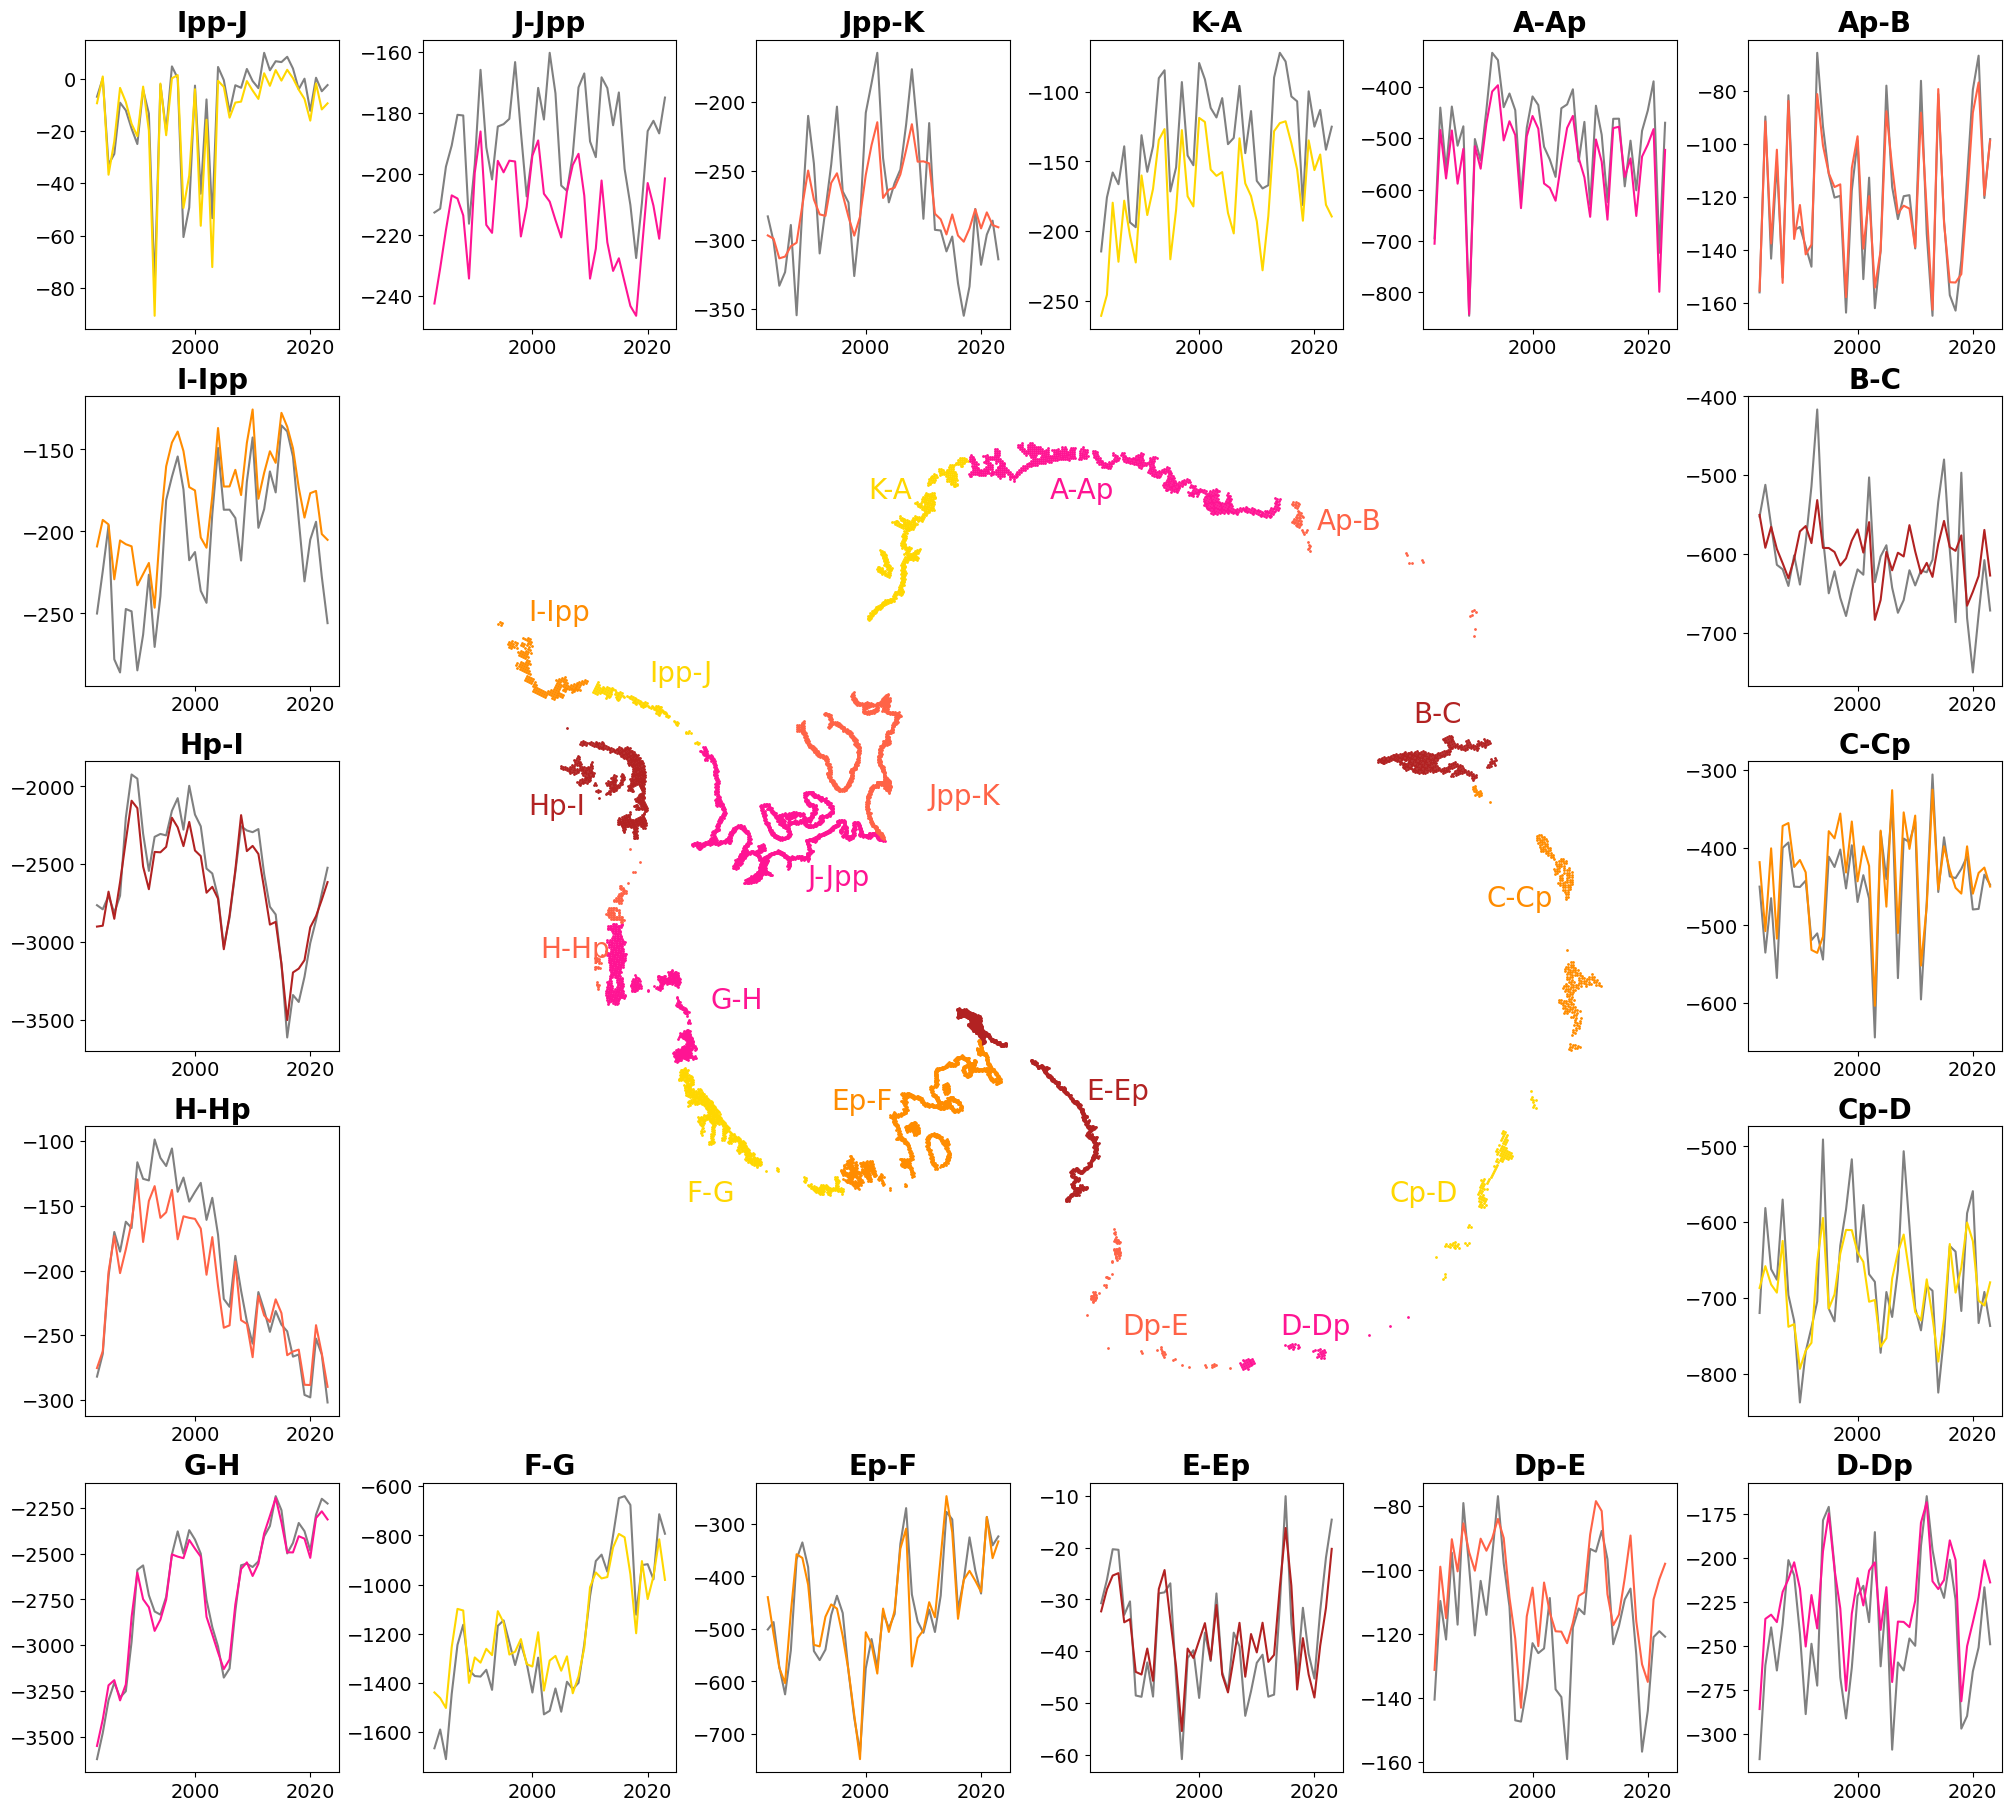

In [38]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (20,18))
widths = [4,4,4,4,4,4]
heights = [4,4,4,4,4]
gs = fig.add_gridspec(5,6, width_ratios = widths, height_ratios = heights)
#for i,j in itertools.product(range(5),range(6)):
#    fig.add_subplot(gs[i,j])

titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
          'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
          'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
          'Ipp-J', 'J-Jpp', 'Jpp-K']
coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
          (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
          (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
          (0.3,0.52), (0.4,0.60)]

ax[17] = fig.add_subplot(gs[1:4,1:5], projection= proj)

for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = ax[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,5)], \
                   transform = trans, s= 1)    
    ax[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                   fontsize = 20, color = colors[np.mod(i,5)])
ax[17].axis('off')


plot_i = [0,0,0,1,2,3,4,4,4,4,4,4,3,2,1,0,0,0]
plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
for i in range(18):
    ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    ax[i].plot(bym2.year, bym2.melt_Gt_per_y, color = 'grey')
    ax[i].plot(bym2.year, bym2.melt_pred_Gt, color = colors[np.mod(i,5)])
    ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold')
    ax[i].tick_params(axis='both', which='major', labelsize=14)
    #ax[i].plot(bym2.year, bym2.melt_Gt_per_y-  bym2.melt_pred_Gt, color = colors[np.mod(i,5)])        


In [39]:
mean_diff = np.ones(18)
mean_diffm = np.ones(18)
mean_percent = np.ones(18)
mean_percentm = np.ones(18)
for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    difference = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)
    percent = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)*100/bym2.melt_Gt_per_y
    mean_diff[i] = (np.mean(difference))
    mean_percent[i] = (np.max(np.abs(percent)))
    mask = np.in1d(bym.basin, regions[i])
    bym3 = bym[mask].groupby(['year','month'], as_index = False).sum()
    difference = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)
    percent = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)*100/bym3.melt_Gt_per_y
    mean_diffm[i] = (np.mean(difference))
    mean_percentm[i] = (np.max(np.abs(percent)))

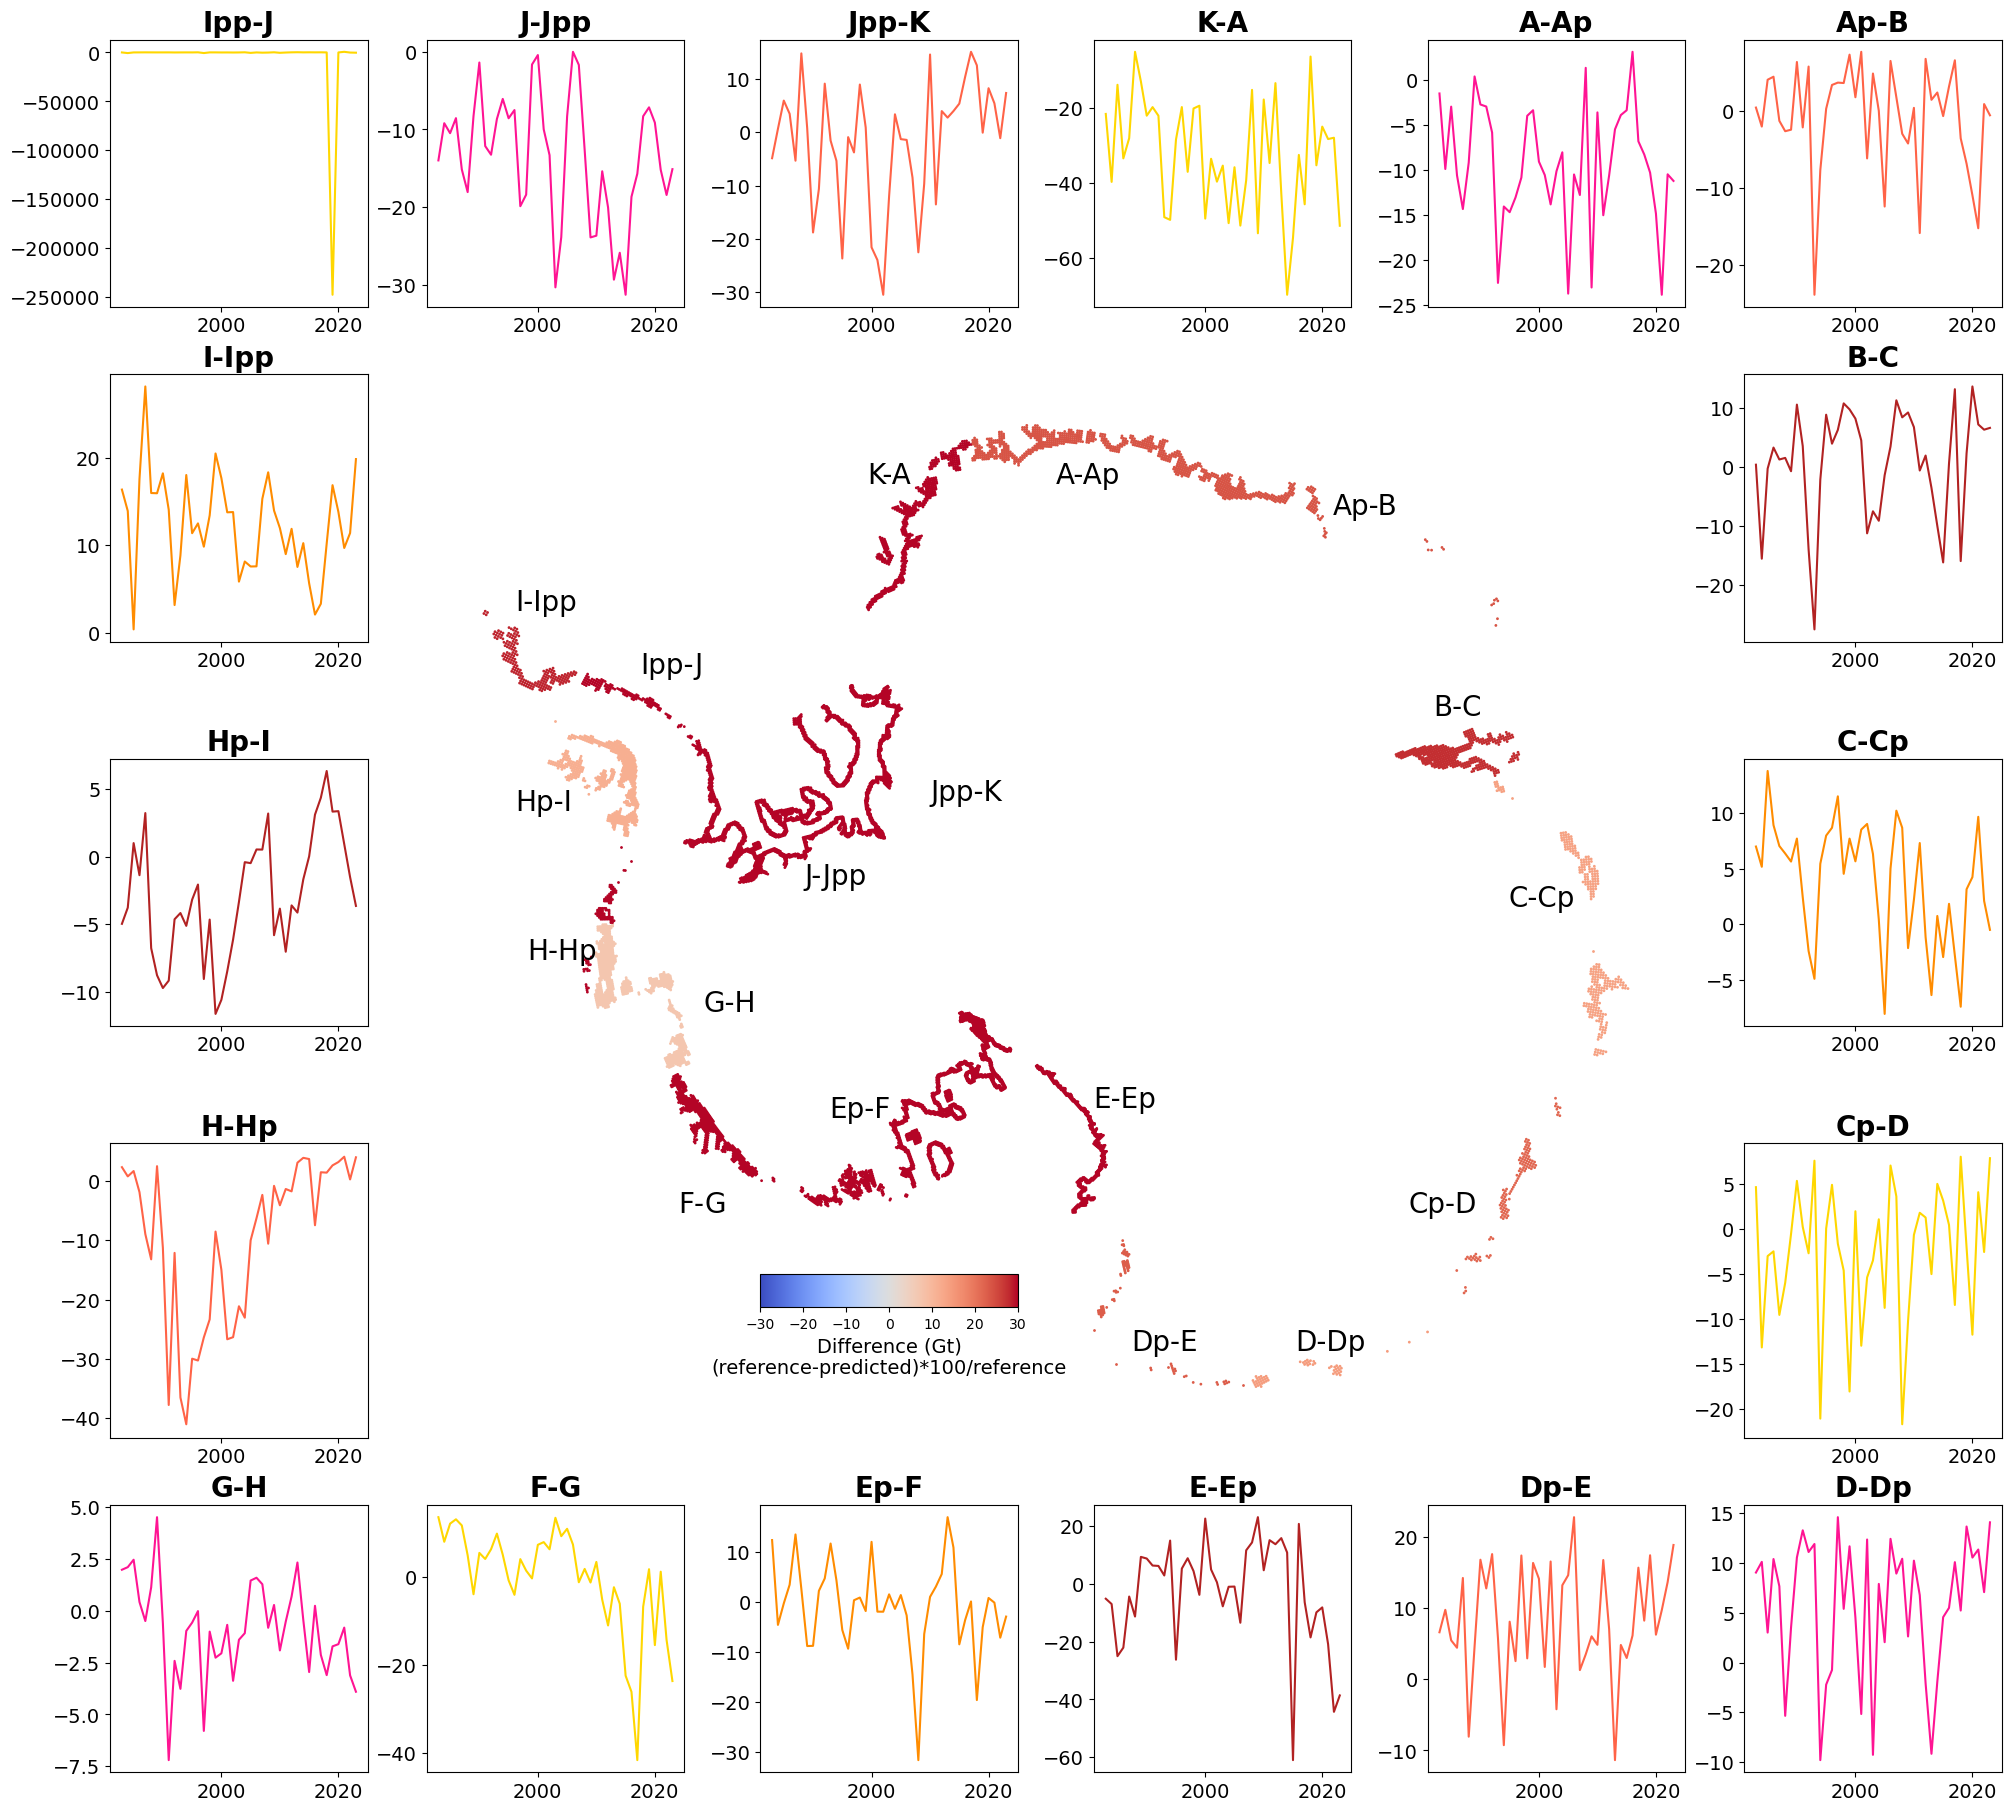

In [40]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (20,18))
widths = [4,4,4,4,4,4]
heights = [4,4,4,0.01,0.5,0.01,4]
gs = fig.add_gridspec(7,6, width_ratios = widths, height_ratios = heights)
#for i,j in itertools.product(range(5),range(6)):
#    fig.add_subplot(gs[i,j])

titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
          'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
          'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
          'Ipp-J', 'J-Jpp', 'Jpp-K']
coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
          (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
          (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
          (0.3,0.52), (0.4,0.60)]

ax[19] = fig.add_subplot(gs[4,2])
ax[18] = fig.add_subplot(gs[1:6,1:5], projection= proj)

for i in range(len(regions)):
    for j in range(len(regions[i])):
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = ax[18].scatter(basin.lon, basin.lat, c = np.ones(len(basin.lon))* mean_percent[i], \
                   transform = trans, s= 1, cmap = 'coolwarm')
        im.set_clim(-30,30)
    ax[18].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                   fontsize = 20, color = 'k')
cbar = plt.colorbar(im, cax = ax[19], orientation = 'horizontal')
cbar.set_label('Difference (Gt)\n(reference-predicted)*100/reference', fontsize = 14)
ax[18].axis('off')


plot_i = [0,0,0,1,2,3,6,6,6,6,6,6,3,2,1,0,0,0]
plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
for i in range(18):
    if plot_i[i] == 3:
        ax[i] = fig.add_subplot(gs[3:6, plot_j[i]])
    else:
        ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    difference = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt)
    percent = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt) * (100/bym2.melt_Gt_per_y)
    #ax[i].plot(bym2.year, bym2.melt_Gt_per_y, color = 'grey')
    #ax[i].plot(bym2.year, bym2.melt_pred_Gt, color = colors[np.mod(i,5)])
    ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold')
    ax[i].tick_params(axis='both', which='major', labelsize=14)
    ax[i].plot(bym2.year, percent, color = colors[np.mod(i,5)])  

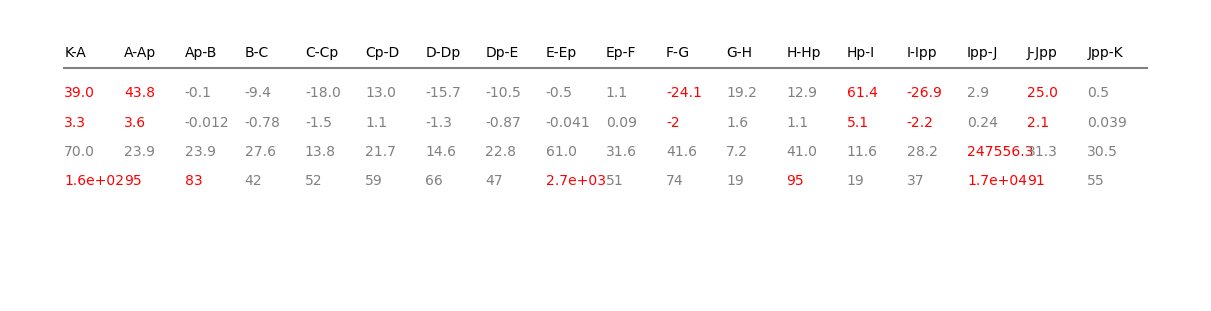

In [41]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (12,3))
widths = [1]
heights = [1]
gs = fig.add_gridspec(1,1, width_ratios = widths, height_ratios = heights)
ax = fig.add_subplot(gs[0,0])
ax.axis('off')
ax.plot(np.arange(0,19), np.ones(19)*0.8, color = 'grey')
ax.set_ylim(0,1)
for i in range(len(titles)):
    ax.annotate(titles[i], xy = (0,0), xytext = (i,0.84), xycoords = 'data')
    if np.abs(mean_diff[i]) < 20:
        fontcolor = 'grey'
    else:
        fontcolor = 'red'
    ax.annotate('{:.1f}'.format(mean_diff[i]), xy = (0,0), xytext = (i, 0.7), xycoords = 'data', color = fontcolor)
    if np.abs(mean_diffm[i]) < 20/12:
        fontcolor = 'grey'
    else:
        fontcolor = 'red'
    ax.annotate('{:.2g}'.format(mean_diffm[i]), xy = (0,0), xytext = (i, 0.6), xycoords = 'data', color = fontcolor)
    if np.abs(mean_percent[i]) < 75:
        fontcolor = 'grey'
    else:
        fontcolor = 'red'
    ax.annotate('{:.1f}'.format(mean_percent[i]), xy = (0,0), xytext = (i, 0.5), xycoords = 'data', color = fontcolor)
    if np.abs(mean_percentm[i]) < 75:
        fontcolor = 'grey'
    else:
        fontcolor = 'red'
    ax.annotate('{:.2g}'.format(mean_percentm[i]), xy = (0,0), xytext = (i, 0.4), xycoords = 'data', color = fontcolor)

In [42]:
i = 15
mask = np.in1d(bym.basin, regions[i])
bym2 = bym[mask].groupby(['year'], as_index = False).sum()
difference = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt)
percent = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt) * (100/bym2.melt_pred_Gt)

Ipp-J


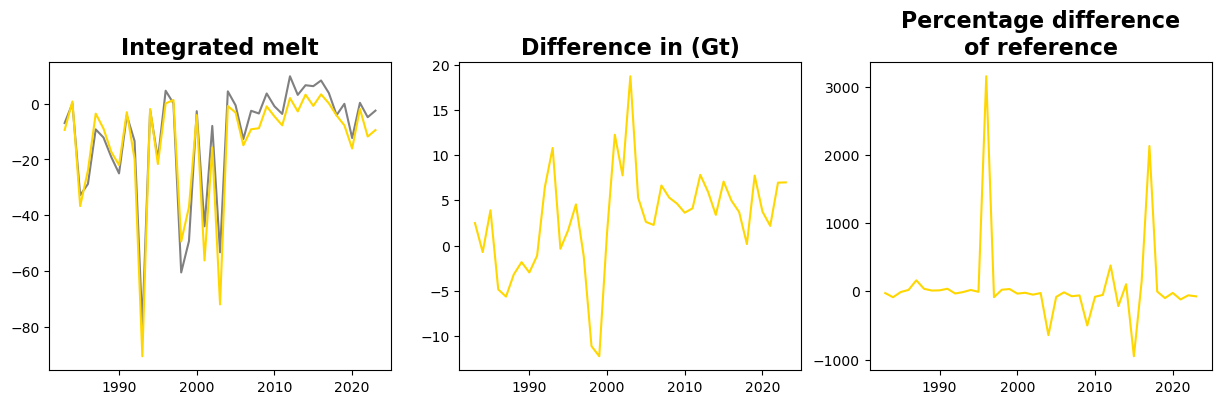

In [43]:
#mask = np.in1d(bym.basin, regions[i])
#bym2 = bym[mask].groupby(['year'], as_index = False).sum()
#difference = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt)
#percent = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt) * (100/bym2.melt_Gt_per_y)
fig, ax = plt.subplots(1,3,figsize = (15,4))
ax[0].plot(bym2.year, bym2.melt_Gt_per_y, color = 'grey')
ax[0].plot(bym2.year, bym2.melt_pred_Gt, color = colors[np.mod(i,5)])
ax[1].plot(bym2.year, difference, color = colors[np.mod(i,5)])
ax[2].plot(bym2.year, percent, color = colors[np.mod(i,5)])
here_titles = ('Integrated melt', 'Difference in (Gt)', 'Percentage difference\nof reference')
for j in range(3):
    ax[j].set_title(here_titles[j], fontsize = 16, fontweight = 'bold')
print(titles[i])

In [44]:
sorted_basin.basins_NEMO.values

array([  1.,   2.,   3.,   4.,   6.,   7.,   8.,   9.,  11.,  12.,  13.,
        14.,  15.,  16.,  17.,  18.,  19.,  21.,  22.,  23.,  24.,  25.,
        26.,  27.,  28.,  29.,  31.,  32.,  34.,  35.,  36.,  37.,  38.,
        40.,  41.,  42.,  44.,  45.,  46.,  47.,  49.,  50.,  51.,  52.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  97.,  98.,  99.,
       100., 101., 102., 103., 104., 105., 107., 108., 110., 111., 113.,
       115., 116., 117., 118., 119., 120., 121., 122., 124., 125., 126.,
       127., 128., 129., 130., 132., 133., 134., 135., 136., 137., 138.,
       139., 140., 141., 142., 143., 144., 145., 146., 147., 148., 149.,
       150., 151., 152., 153., 154., 155.])

In [45]:
[np.argmax(ref_means)]

[104]

(-80.0, 5.0)

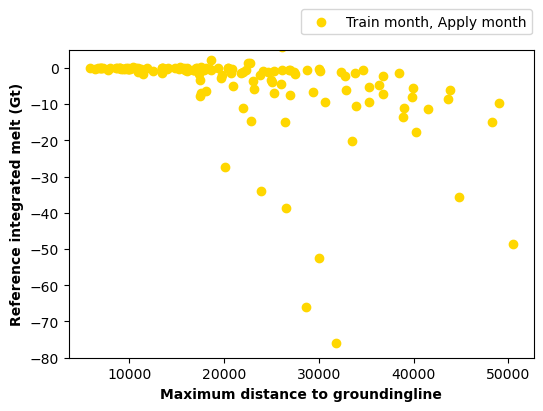

In [46]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.scatter(sorted_basin_max.distances_GL,ref_means, color = 'gold', label = 'Train month, Apply month')
#ax.scatter(sorted_basin_max.distances_Gl,(tmay_means-ref_means), color = 'pink', label = 'Train month, Apply year')
#ax.scatter(sorted_basin_max.distances_GL,(tyam_means-ref_means), color = 'darkgoldenrod', label = 'Train year, apply month')
#ax.scatter(sorted_basin_max.distances_GL,(tyay_means-ref_means), color = 'purple', label = 'Train year, apply year')
ax.legend(loc = (0.5,1.05))
ax.set_xlabel('Maximum distance to groundingline', fontweight = 'bold')
ax.set_ylabel('Reference integrated melt (Gt)', fontweight = 'bold')
ax.set_ylim(-80,5)

Text(0, 0.5, 'Difference in integrated melt (Gt)\n(Predicted - Reference)')

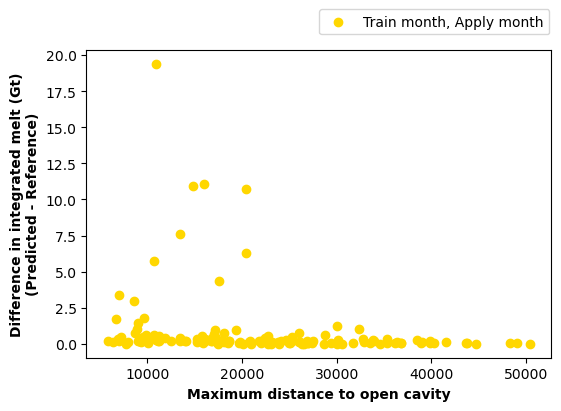

In [47]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.scatter(sorted_basin_max.distances_GL,np.abs(tmam_means - ref_means)/np.abs(ref_means), color = 'gold', label = 'Train month, Apply month')
#ax.scatter(sorted_basin_max.distances_GL,np.abs(tmay_means-ref_means)/np.abs(ref_means), color = 'pink', label = 'Train month, Apply year')
#ax.scatter(sorted_basin_max.distances_GL,np.abs(tyam_means-ref_means)/np.abs(ref_means), color = 'darkgoldenrod', label = 'Train year, apply month')
#ax.scatter(sorted_basin_max.distances_GL,np.abs(tyay_means-ref_means)/np.abs(ref_means), color = 'purple', label = 'Train year, apply year')
ax.legend(loc = (0.5,1.05))
ax.set_xlabel('Maximum distance to open cavity', fontweight = 'bold')
ax.set_ylabel('Difference in integrated melt (Gt)\n(Predicted - Reference)', fontweight = 'bold')

Text(0, 0.5, 'Difference in integrated melt (Gt)\n(Predicted - Reference)')

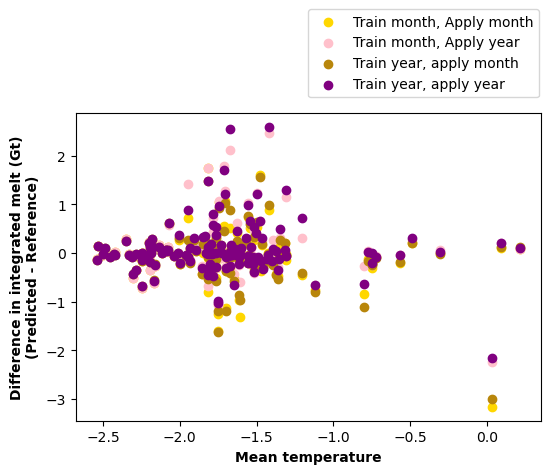

In [48]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.scatter(sorted_basin.mean_T,(tmam_means - ref_means), color = 'gold', label = 'Train month, Apply month')
ax.scatter(sorted_basin.mean_T,(tmay_means-ref_means), color = 'pink', label = 'Train month, Apply year')
ax.scatter(sorted_basin.mean_T,(tyam_means-ref_means), color = 'darkgoldenrod', label = 'Train year, apply month')
ax.scatter(sorted_basin.mean_T,(tyay_means-ref_means), color = 'purple', label = 'Train year, apply year')
ax.legend(loc = (0.5,1.05))
ax.set_xlabel('Mean temperature', fontweight = 'bold')
ax.set_ylabel('Difference in integrated melt (Gt)\n(Predicted - Reference)', fontweight = 'bold')

Text(0, 0.5, 'Difference in integrated melt (Gt)\n(Predicted - Reference)')

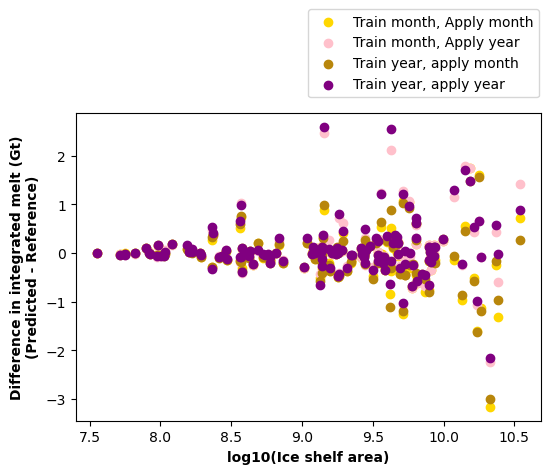

In [49]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.scatter(np.log10(areas),(tmam_means-ref_means), color = 'gold', label = 'Train month, Apply month')
ax.scatter(np.log10(areas),(tmay_means-ref_means), color = 'pink', label = 'Train month, Apply year')
ax.scatter(np.log10(areas),(tyam_means-ref_means), color = 'darkgoldenrod', label = 'Train year, apply month')
ax.scatter(np.log10(areas),(tyay_means-ref_means), color = 'purple', label = 'Train year, apply year')
ax.legend(loc = (0.5,1.05))
ax.set_xlabel('log10(Ice shelf area)', fontweight = 'bold')
ax.set_ylabel('Difference in integrated melt (Gt)\n(Predicted - Reference)', fontweight = 'bold')

(-1.8, 2.75)

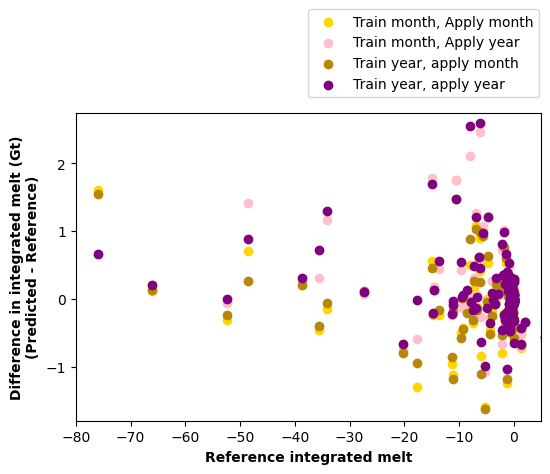

In [50]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.scatter(ref_means,(tmam_means - ref_means), color = 'gold', label = 'Train month, Apply month')
ax.scatter(ref_means,(tmay_means - ref_means), color = 'pink', label = 'Train month, Apply year')
ax.scatter(ref_means,(tyam_means - ref_means), color = 'darkgoldenrod', label = 'Train year, apply month')
ax.scatter(ref_means,(tyay_means - ref_means), color = 'purple', label = 'Train year, apply year')
ax.legend(loc = (0.5,1.05))
ax.set_xlabel('Reference integrated melt', fontweight = 'bold')
ax.set_ylabel('Difference in integrated melt (Gt)\n(Predicted - Reference)', fontweight = 'bold')
plt.xlim(-80,5)
plt.ylim(-1.8,2.75)

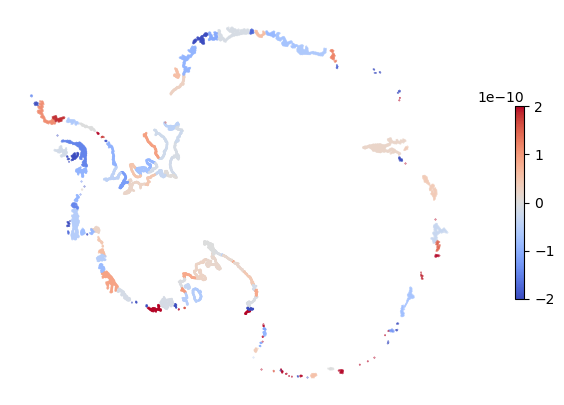

In [51]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
for i in range(len(basin_nos)):
    basin = latlonbasin[latlonbasin.basin == basin_nos[i]]
   # print(tmam_means[i] - ref_means[i])
    im = plt.scatter(basin.lon, basin.lat, c = np.ones(len(basin.lon))* (tmam_means[i]-ref_means[i])/areas[i], \
                   transform = trans, s= 0.1, cmap = 'coolwarm')
    im.set_clim(-2e-10,2e-10)    
plt.colorbar(shrink = 0.5)

ax.axis('off');
    

(0.0, 2.0)

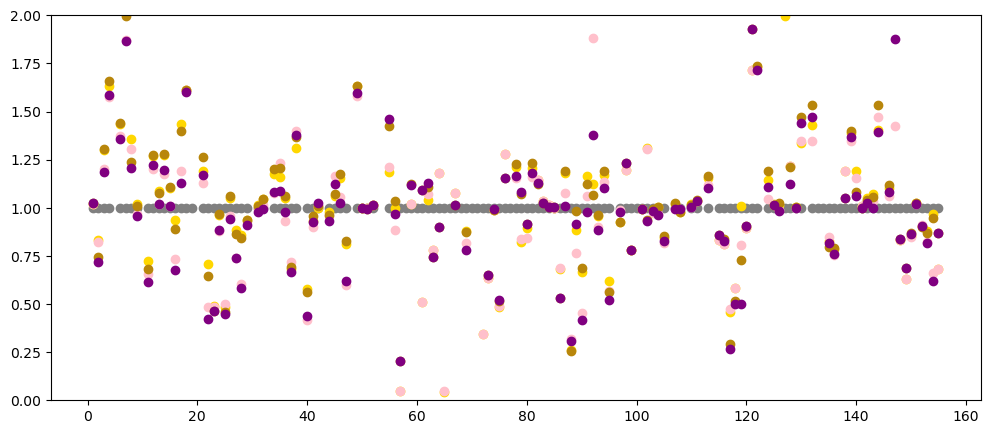

In [52]:
fig, ax = plt.subplots(1,1,figsize = (12,5))
plt.scatter(basin_nos, ref_means/ref_means, color = 'grey')
plt.scatter(basin_nos, tmam_means/ref_means, color = 'gold')
plt.scatter(basin_nos, tmay_means/ref_means, color = 'pink')
plt.scatter(basin_nos, tyam_means/ref_means, color = 'darkgoldenrod')
plt.scatter(basin_nos, tyay_means/ref_means, color = 'purple')
ax.set_ylim(0,2)

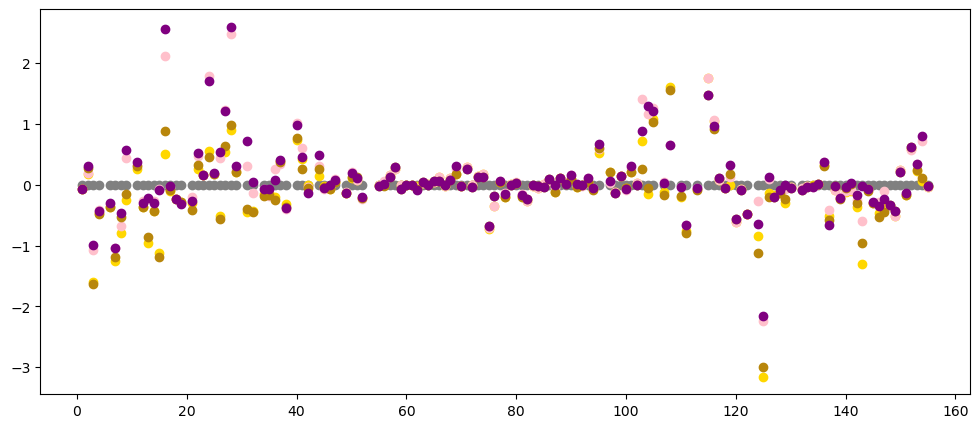

In [53]:
fig, ax = plt.subplots(1,1,figsize = (12,5))
plt.scatter(basin_nos, ref_means-ref_means, color = 'grey')
plt.scatter(basin_nos, tmam_means-ref_means, color = 'gold')
plt.scatter(basin_nos, tmay_means-ref_means, color = 'pink')
plt.scatter(basin_nos, tyam_means-ref_means, color = 'darkgoldenrod')
plt.scatter(basin_nos, tyay_means-ref_means, color = 'purple')
#ax.set_ylim(-0.000000001,0.000000001)

Text(0, 0.5, 'Difference to predicted melt')

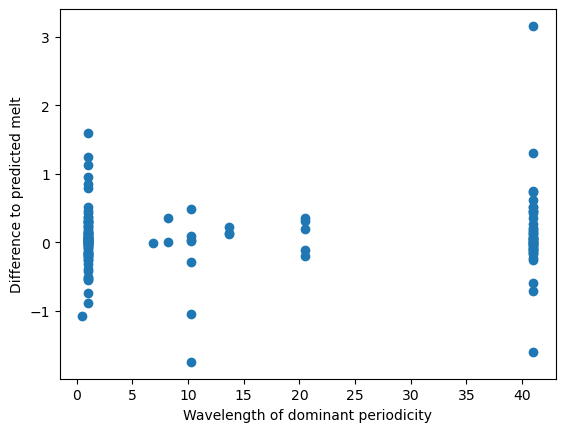

In [54]:
plt.scatter(wavs, (ref_means - tmam_means))
plt.xlabel('Wavelength of dominant periodicity')
plt.ylabel('Difference to predicted melt')

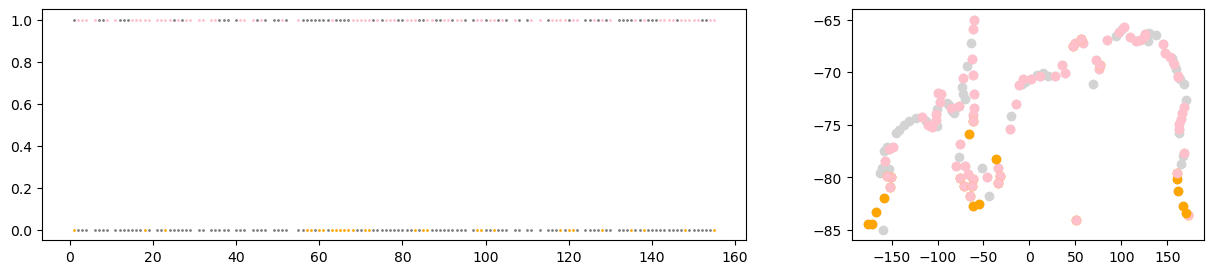

In [55]:
fig, ax = plt.subplots(1,2, figsize = (15,3), width_ratios = (10,5))
plt.scatter(lon_means, lat_means, color = 'lightgrey')
for i in range(len(basin_nos)):
    if np.abs(tmam_means[i] - tmay_means[i]) < 0.001:
        plt.scatter(lon_means[i], lat_means[i], color = 'orange')
        ax[0].scatter(basin_nos[i], 0, color = 'orange', s = 1)
    else:
        ax[0].scatter(basin_nos[i], 0, color = 'grey', s = 1)
    if (np.abs(tmam_means[i] - tmay_means[i]) < np.abs(tyam_means[i] - tyay_means[i])):
        plt.scatter(lon_means[i], lat_means[i], color = 'pink')
        ax[0].scatter(basin_nos[i], 1, color = 'pink', s = 1)
    else:
        ax[0].scatter(basin_nos[i], 1, color = 'grey', s = 1)

In [56]:
import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

In [57]:
mask_applyimport = np.abs(tmam_means - tmay_means) < 0.1 * np.abs(tmam_means - tyam_means)
mask_trainimport = 0.1*np.abs(tmam_means - tmay_means) > np.abs(tmam_means - tyam_means)

[  3.   6.  12.  14.  15.  19.  24.  26.  28.  31.  32.  47.  49.  52.
  69.  87.  88.  92.  97.  99. 101. 104. 108. 151. 154.]


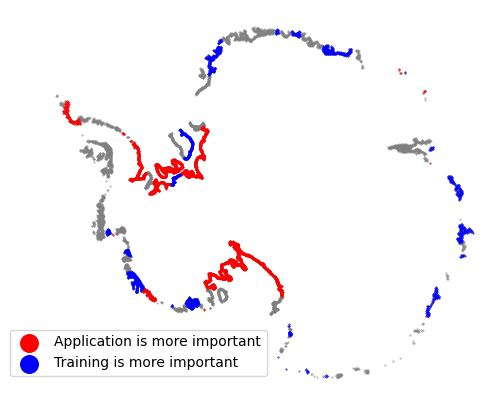

In [58]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})

plt.scatter(latlonbasin.lon, latlonbasin.lat, s = 0.1, transform = trans, color = 'grey')
for i in basin_nos[mask_applyimport]:
    basin = latlonbasin[latlonbasin.basin == i]
    if i == basin_nos[mask_applyimport][0]:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'red', label = 'Application is more important')
    else:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'red')
for i in basin_nos[mask_trainimport]:
    basin = latlonbasin[latlonbasin.basin == i]
    if i == basin_nos[mask_trainimport][0]:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'blue', label = 'Training is more important')
    else:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'blue')
print(basin_nos[mask_trainimport])
ax.axis('off')
plt.title('')
ax.legend(markerscale = 40, loc = (-0.055,0.05))

In [59]:
#tmam - tmay is the difference in applying month vs year 
#tmam - tyam is the difference in training month vs year 
#if tmam-tmay is big and tmam-tyam is small, then tmam-tmay - tmam-tyam is positive 
#and applying month vs year has more of an impact than training
#if tmam-tmay is small and tmam-tyam is big, then tmam-tmay - tmam-tyam is negative 
#and training month vs year has more of an impact than applying 

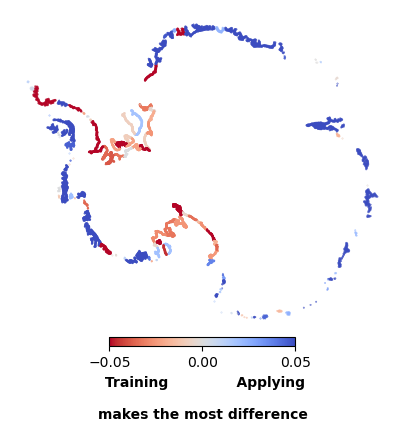

In [60]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
for i in range(len(basin_nos)):
    basin = latlonbasin[latlonbasin.basin == basin_nos[i]]
    im = plt.scatter(basin.lon, basin.lat, c = np.ones(len(basin.lon))*np.abs(tmam_means[i] - tmay_means[i])-np.abs(tmam_means[i] - tyam_means[i]), 
                 cmap = 'coolwarm_r', transform = trans, s = 0.1)
    im.set_clim(-0.05,0.05)
ax.axis('off');
cbar = plt.colorbar(shrink = 0.2, orientation = 'horizontal', pad = 0.01)
cbar.set_ticks((-0.05,0,0.05))
cbar.set_label(' Training              Applying\n\nmakes the most difference', fontweight = 'bold')

In [61]:
#Annual pattern 1,2,3, 13
#Not annual pattern 0, 11

In [62]:
ref_pred1 = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset')
ref_pred = ref_pred1[ref_pred1.year > 1980]
yr_basin = ref_pred.groupby(['year','month', 'basin'], as_index = False).sum()
yr_basinm = ref_pred.groupby(['year','month', 'basin'], as_index = False).mean()

/tmp/ipykernel_1254174/1721698199.py:11: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(1/wav, fft)


Text(0, 0.5, 'Fourier coefficient')

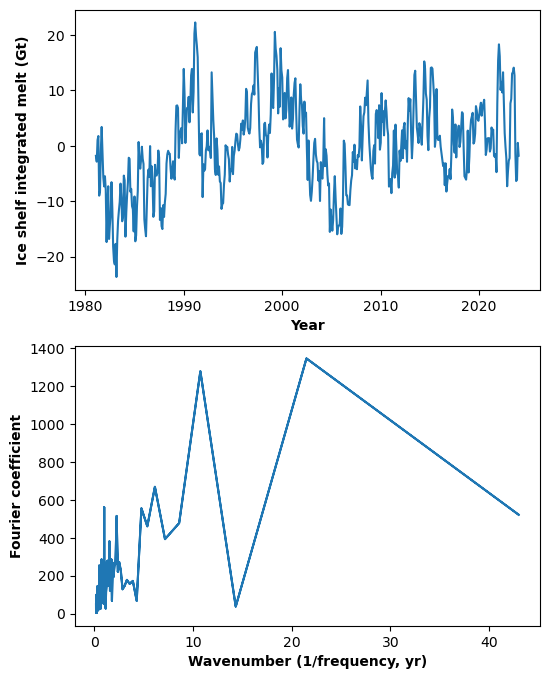

In [63]:
fig, ax =plt.subplots(2,1, figsize = (6,8))
i = 41
yr_basin_sel = yr_basin[yr_basin.basin == basin_nos[i]]
zero = yr_basin_sel.melt_Gt_per_y.values - np.mean(yr_basin_sel.melt_Gt_per_y.values)
grad = (zero[-1]- zero[0])/len(zero)
slope = grad * np.arange(0,len(yr_basin_sel.melt_Gt_per_y.values),1)
fft = np.abs(np.fft.fft(zero-slope-np.mean(zero-slope)))
fft[0] = np.nan
wav = np.abs(np.fft.fftfreq(len(yr_basin_sel.melt_Gt_per_y.values), 1/12))
#print(i, 1/wav[np.nanargmax(fft)], fft[np.nanargmax(fft)])
ax[1].plot(1/wav, fft)
ax[0].plot(yr_basin_sel.year+yr_basin_sel.month/12, zero-slope - np.mean(zero-slope))
fontsize = 10
fontweight = 'bold'
ax[0].set_xlabel('Year', fontsize = fontsize, fontweight = fontweight)
ax[0].set_ylabel('Ice shelf integrated melt (Gt)', fontsize = fontsize, fontweight = fontweight)
ax[1].set_xlabel('Wavenumber (1/frequency, yr)', fontsize = fontsize, fontweight = fontweight)
ax[1].set_ylabel('Fourier coefficient', fontsize = fontsize, fontweight = fontweight)

/tmp/ipykernel_1254174/2415626109.py:11: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(1/wav, fft)


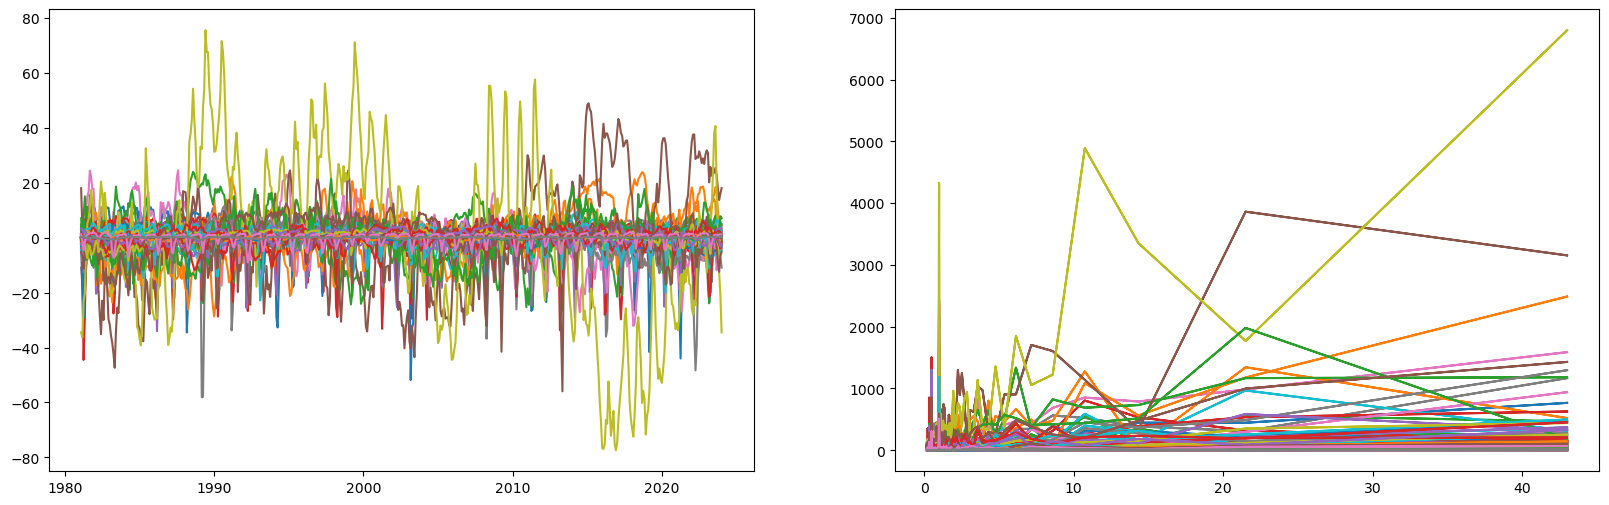

In [64]:
fig, ax =plt.subplots(1,2, figsize = (20,6))
for i in range(len(basin_nos)):
    yr_basin_sel = yr_basin[yr_basin.basin == basin_nos[i]]
    zero = yr_basin_sel.melt_Gt_per_y.values - np.mean(yr_basin_sel.melt_Gt_per_y.values)
    grad = (zero[-1]- zero[0])/len(zero)
    slope = grad * np.arange(0,len(yr_basin_sel.melt_Gt_per_y.values),1)
    fft = np.abs(np.fft.fft(zero-slope-np.mean(zero-slope)))
    fft[0] = np.nan
    wav = np.abs(np.fft.fftfreq(len(yr_basin_sel.melt_Gt_per_y.values), 1/12))
    #print(i, 1/wav[np.nanargmax(fft)], fft[np.nanargmax(fft)])
    ax[1].plot(1/wav, fft)
    ax[0].plot(yr_basin_sel.year+yr_basin_sel.month/12, zero-slope - np.mean(zero-slope))
    #ax[0].plot(yr_basin_sel.year+yr_basin_sel.month/12, yr_basin_sel.melt_Gt_per_y, color = 'lightgrey', zorder = 0)

[  3.   6.  12.  14.  15.  19.  24.  26.  28.  31.  32.  47.  49.  52.
  69.  87.  88.  92.  97.  99. 101. 104. 108. 151. 154.]


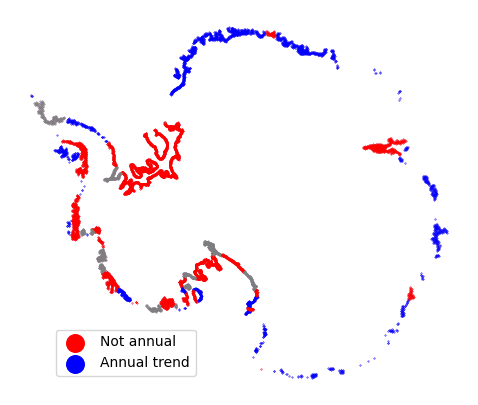

In [65]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})

plt.scatter(latlonbasin.lon, latlonbasin.lat, s = 0.001, transform = trans, color = 'red', label = 'Not annual')
plt.scatter(latlonbasin.lon, latlonbasin.lat, s = 0.001, transform = trans, color = 'blue', label = 'Annual trend')
for i in range(len(basin_nos)):
    basin = latlonbasin[latlonbasin.basin == basin_nos[i]]
    if wavs[i] > 30:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'red')
    elif wavs[i] == 1:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'blue')
    else:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'grey')
print(basin_nos[mask_trainimport])
ax.axis('off')
plt.title('')
ax.legend(markerscale = 400, loc = (0.1,0.05))

[2.0, 3.0, 4.0, 6.0, 7.0, 9.0, 11.0, 12.0, 13.0, 15.0, 16.0, 17.0, 18.0, 19.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 32.0, 34.0, 35.0, 36.0, 37.0, 38.0, 40.0, 41.0, 42.0, 44.0, 45.0, 46.0, 47.0, 55.0, 56.0, 62.0, 69.0, 70.0, 73.0, 77.0, 78.0, 79.0, 80.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 97.0, 100.0, 113.0, 117.0, 118.0, 119.0, 124.0, 126.0, 127.0, 128.0, 130.0, 133.0, 134.0, 135.0, 136.0, 139.0, 140.0, 144.0, 145.0, 147.0, 150.0, 153.0, 154.0]
[1.0, 8.0, 14.0, 31.0, 49.0, 57.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 72.0, 74.0, 75.0, 81.0, 82.0, 83.0, 84.0, 85.0, 98.0, 99.0, 103.0, 105.0, 110.0, 111.0, 116.0, 120.0, 121.0, 122.0, 125.0, 137.0, 138.0, 143.0, 146.0, 148.0, 149.0, 151.0, 152.0]
[50.0, 51.0, 52.0, 58.0, 59.0, 60.0, 61.0, 71.0, 76.0, 101.0, 102.0, 104.0, 107.0, 108.0, 115.0, 129.0, 132.0, 141.0, 142.0, 155.0]


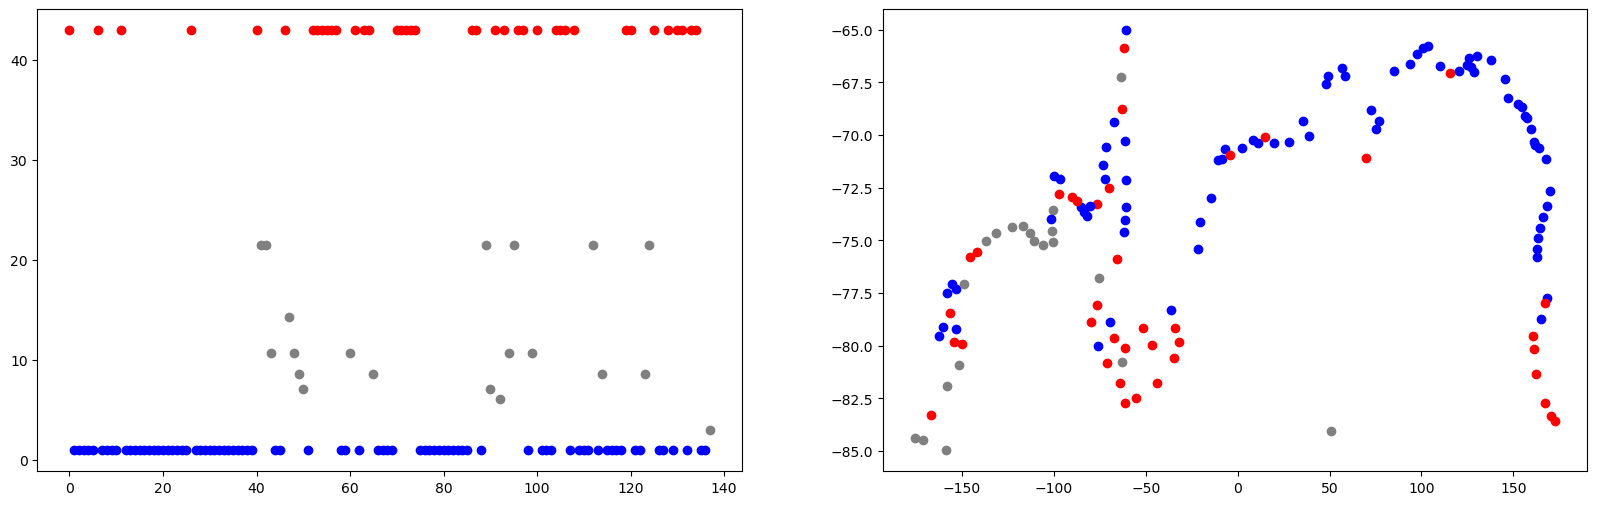

In [66]:
fig, ax =plt.subplots(1,2, figsize = (20,6))
not_annual = []
annual = []
others = []
for i in range(len(basin_nos)):
    yr_basin_sel = yr_basin[yr_basin.basin == basin_nos[i]]
    yr_basin_selm = yr_basinm[yr_basin.basin == basin_nos[i]]
    zero = yr_basin_sel.melt_Gt_per_y.values - np.mean(yr_basin_sel.melt_Gt_per_y.values)
    grad = (zero[-1]- zero[0])/len(zero)
    slope = grad * np.arange(0,len(yr_basin_sel.melt_Gt_per_y.values),1)
    fft = np.abs(np.fft.fft(zero-slope-np.mean(zero-slope)))
    fft[0] = np.nan
    wav = np.abs(np.fft.fftfreq(len(yr_basin_sel.melt_Gt_per_y.values), 1/12))
    #ax[0].scatter(i, 1/wav[np.nanargmax(fft)])
    #ax[1].scatter(i, fft[np.nanargmax(fft)])
    if 1/wav[np.nanargmax(fft)] > 30:
        ax[1].scatter(np.mean(yr_basin_selm.lon), np.mean(yr_basin_selm.lat), c = 'red')    
        ax[0].scatter(i, 1/wav[np.nanargmax(fft)], color = 'red')
        not_annual.append(basin_nos[i])
    elif 1/wav[np.nanargmax(fft)] == 1.0:
        ax[1].scatter(np.mean(yr_basin_selm.lon), np.mean(yr_basin_selm.lat), c = 'blue')  
        ax[0].scatter(i, 1/wav[np.nanargmax(fft)], color = 'blue')
        annual.append(basin_nos[i])
    else:
        ax[1].scatter(np.mean(yr_basin_selm.lon), np.mean(yr_basin_selm.lat), c = 'grey')    
        ax[0].scatter(i, 1/wav[np.nanargmax(fft)], color = 'grey')
        others.append(basin_nos[i])
#    im = ax[1].scatter(np.mean(yr_basin_selm.lon), np.mean(yr_basin_selm.lat), c = 1/wav[np.nanargmax(fft)]) 
#    im.set_clim(0,25)
#plt.colorbar(im, ax = ax[1])    
print(annual)
print(not_annual)
print(others)

In [67]:
i = 31
yr_basin_sel = yr_basin[yr_basin.basin == basin_nos[i]]

In [68]:
zero = yr_basin_sel.melt_Gt_per_y.values - np.mean(yr_basin_sel.melt_Gt_per_y.values)
grad = (zero[-1]- zero[0])/len(zero)
slope = grad * np.arange(0,len(yr_basin_sel.melt_Gt_per_y.values),1)

In [69]:
print(i, 1/wav[np.nanargmax(fft)], fft[np.nanargmax(fft)])

31 3.071428571428571 28.62674184623522


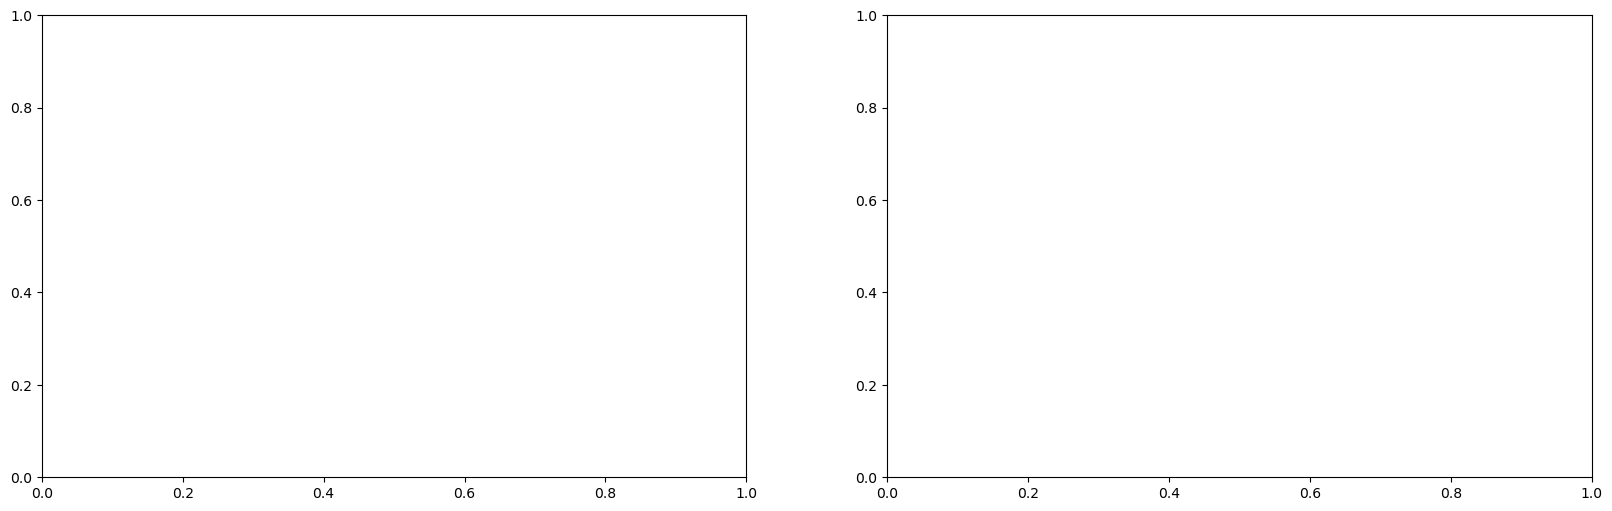

In [70]:
fig, ax =plt.subplots(1,2, figsize = (20,6))


In [71]:
# Look at the annual data 
def annual_comp(this_collection, exp_name, keep_all_runs = True, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, 
                   apply_collection = None):
    ref_pred = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset')
    ref_pred_annual = load_results_nn(this_collection, exp_name, verbose, annual_only = 'True', apply_collection = 'whole_dataset')
    ref_pred_af = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset', \
                                   annual_f = 'annual_')
    ref_pred_annual_af = load_results_nn(this_collection, exp_name, verbose, annual_only = 'True', apply_collection = 'whole_dataset', \
                                             annual_f = 'annual_')
    tmay = ref_pred_annual.groupby(['year'], as_index = False).sum()
    ref_pred_monthly = ref_pred.groupby(['lat','lon','year'], as_index = False).mean()
    tmam = ref_pred_monthly.groupby(['year'], as_index = False).sum()
    tyay = ref_pred_annual_af.groupby(['year'], as_index = False).sum()
    ref_pred_monthly = ref_pred_af.groupby(['lat','lon','year'], as_index = False).mean()
    tyam = ref_pred_monthly.groupby(['year'], as_index = False).sum()
    # Train month apply year
    # Train month apply month
    # Train year apply year
    # Train year apply month
    return tmay, tmam, tyay, tyam  